In [ ]:
# bootstrap: raiz do projeto
import os, pathlib
_r = pathlib.Path.cwd()
while not (_r / 'CLAUDE.md').exists() and _r != _r.parent:
    _r = _r.parent
os.chdir(_r)

# Incremento de features **canal** e **produto** — Quantidade e Valor

Testa se enriquecer os modelos pré-selecionados com informação de **canal** (`canalid` →
`crefaz.dim_canal.nome`) e **produto** (`produtoid` → `crefaz.dim_produto.produto`) melhora a
previsão diária frente à **pipeline antiga em produção**.

**Modelos avaliados**
- **Quantidade:** `SE(LINE)+SE(SGDR)+ABR`, `SE(ETR)+MMS+BIN+SE(ELAS)+ABR`
- **Valor:** `SE(ETR)+ABR`, `ExtraTrees(EXT,j90)`, `Voting(GBR+XGB+RFR)`

**Variantes de feature** (cada modelo roda em todas):
- `base`     — features atuais (BASE para qtd/valor; EXT para o ExtraTrees)
- `+mix`     — share do canal e do produto **principais de ontem** (2 features)
- `+seg`     — **volume por segmento** (cada canal e cada produto) em **vários lags** (`SEG_LAGS`),
  cru (sem redução). Qtd: `qtd_<seg>_lag{k}`. Valor: `valor_<seg>_lag{k}` **e** `qtd_<seg>_lag{k}`.
- `+seg_pca` — as mesmas features de `+seg`, mas comprimidas por **StandardScaler + PCA**
  mantendo as componentes que somam **≥80% da variância** (só elas entram; base passa direto).
- `bottom-up` — **abordagem hierárquica**: treina **um modelo por célula `canalid×produtoid`**
  (as `TOP_K_CELLS` maiores + uma célula `outros`), prevê cada célula com as features da
  **própria célula** e **soma** as previsões (clip ≥0) → total do dia. Mede se *desagregar e
  reagregar* supera prever o total direto. As demais variantes são **top-down** (preveem o total).

> **Anti-vazamento:** todas as features de canal/produto são defasadas (1+ dias) e o **PCA é
> re-ajustado por fold** (dentro do `Pipeline`, só no treino). O framework re-treina cada
> arquitetura por fold, então passar a matriz mais larga basta — não altera o `.pkl`.

**Período:** janeiro/2026 em diante. **Métricas:** MAPE, **viés** (erro médio com sinal =
realizado − predito) e **MAE** (magnitude). Mais análise de **safra mensal**.

In [86]:
import pandas as pd
import numpy as np
import warnings
import matplotlib.pyplot as plt
from datetime import datetime, timedelta
import hashlib, pickle, os, copy, sys, types, glob

import clickhouse_connect
from workadays import workdays as wd
from sklearn.base import clone
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.ensemble import (RandomForestRegressor, GradientBoostingRegressor,
                              ExtraTreesRegressor, VotingRegressor, AdaBoostRegressor)
from xgboost import XGBRegressor
import joblib

warnings.filterwarnings('ignore')
pd.set_option('display.float_format', '{:.2f}'.format)
pd.set_option('display.max_columns', 60)
print('Imports OK')

Imports OK


In [87]:
# ==================== CONFIGURAÇÃO COMUM ====================
# Credenciais (mesma infra dos notebooks top15_*). qtd usa um usuário, valor outro.
CRED_QTD = dict(host='10.101.150.150', port=8123, username='daniel_ramazzotte', password='O9pLTAv*yVz0lGP^#M')
CRED_VAL = dict(host='10.101.150.150', port=8123, username='debora_jesus',      password='3fDsSF1$pe1yDv')

JANELA_DIAS = 45     # dias úteis de treino por fold (modelos base)
JANELA_NOVOS = 90    # janela do candidato ExtraTrees(EXT,j90)
INCLUIR_SABADO_TREINO = True
PERIODO_INI = pd.Timestamp('2026-01-01')   # estudo: jan/2026 em diante
SEG_LAGS = [1, 2, 3, 4, 5]   # defasagens das features por segmento (canal/produto)
PCA_VAR  = 0.80              # PCA: nº de componentes que somam >=80% da variância
TOP_K_CELLS = 12             # bottom-up: nº de células canal×produto modeladas (resto -> 'outros')
MODEL_VERSION = 'inc_canalprod_v3_pca80_lag5'   # v3: seg multi-lag -> StandardScaler+PCA(80%)

_cache_dir = 'cache'
os.makedirs(_cache_dir, exist_ok=True)

# ---------- Log de erros operacionais (compartilhado) ----------
_log_erro = pd.read_excel(r'logs\Log_Erro.xlsx')
_log_erro['Data'] = pd.to_datetime(_log_erro['Data'], errors='coerce').dt.normalize()
_log_erro['Impacto/dias'] = pd.to_numeric(_log_erro['Impacto/dias'], errors='coerce').fillna(1).astype(int)
def _bdays_from(_start, _n):
    _out, _d = [], pd.Timestamp(_start).normalize()
    while len(_out) < _n:
        if _d.weekday() < 5 and not wd.is_holiday(_d.date(), country='BR'):
            _out.append(_d)
        _d += pd.Timedelta(days=1)
    return _out
_mapa_erro = {}
for _, _r in _log_erro.dropna(subset=['Data']).iterrows():
    _nome = str(_r['Sistema Erro']).strip()
    for _d in _bdays_from(_r['Data'], max(int(_r['Impacto/dias']), 1)):
        _mapa_erro[_d] = _nome if _d not in _mapa_erro else f'{_mapa_erro[_d]} + {_nome}'
def sistema_erro(d):
    if d is None or pd.isna(d): return 'Sem Erro'
    return _mapa_erro.get(pd.Timestamp(d).normalize(), 'Sem Erro')
print(f'Log_Erro: {len(_log_erro)} eventos | dias afetados: {len(_mapa_erro)}')
print(f'Período de estudo: a partir de {PERIODO_INI.date()}')

Log_Erro: 17 eventos | dias afetados: 31
Período de estudo: a partir de 2026-01-01


In [88]:
# ==================== SHIMS TPOT (para carregar PKL) ====================
class _ZeroCount:
    def fit(self, X, y=None): return self
    def transform(self, X):
        Xa = X.values if hasattr(X, 'values') else np.asarray(X)
        n0 = (Xa == 0).sum(axis=1, keepdims=True).astype(float)
        n1 = (Xa != 0).sum(axis=1, keepdims=True).astype(float)
        return np.hstack([Xa, n0, n1])
    def fit_transform(self, X, y=None): return self.fit(X, y).transform(X)

class _OHE:
    def __init__(self, minimum_fraction=0.05, sparse=True, threshold=10, **kw):
        self.threshold = threshold; self._cat = []; self._ohe = None
    def fit(self, X, y=None):
        from sklearn.preprocessing import OneHotEncoder as _SOHE
        Xa = X.values if hasattr(X, 'values') else np.asarray(X)
        self._cat = [i for i in range(Xa.shape[1]) if len(np.unique(Xa[:, i])) <= self.threshold]
        self._num = [i for i in range(Xa.shape[1]) if i not in self._cat]
        if self._cat:
            self._ohe = _SOHE(sparse_output=False, handle_unknown='ignore')
            self._ohe.fit(Xa[:, self._cat])
        return self
    def transform(self, X):
        Xa = X.values if hasattr(X, 'values') else np.asarray(X)
        parts = [Xa[:, self._num]] if self._num else []
        if self._cat and self._ohe:
            parts.append(self._ohe.transform(Xa[:, self._cat]))
        return np.hstack(parts) if parts else Xa
    def fit_transform(self, X, y=None): return self.fit(X, y).transform(X)

class _SE:
    def __init__(self, estimator=None, **kw): self.estimator = estimator
    def fit(self, X, y=None):
        if self.estimator: self.estimator.fit(X, y)
        return self
    def transform(self, X):
        Xa = X.values if hasattr(X, 'values') else np.asarray(X, dtype=float)
        if self.estimator:
            p = np.atleast_1d(self.estimator.predict(Xa)).reshape(-1, 1).astype(float)
            return np.hstack([Xa, p])
        return Xa
    def fit_transform(self, X, y=None): return self.fit(X, y).transform(X)

class _PassThru:
    def __init__(self, *a, **kw): pass
    def fit(self, X, y=None): return self
    def transform(self, X): return X
    def fit_transform(self, X, y=None): return X

import importlib.abc, importlib.machinery
_SHIM_CLASSES = {'ZeroCount': _ZeroCount, 'OneHotEncoder': _OHE,
                 'StackingEstimator': _SE, 'FeatureSetSelector': _PassThru}
class _ShimModule(types.ModuleType):
    __path__ = []
    def __getattr__(self, name):
        if name in _SHIM_CLASSES: return _SHIM_CLASSES[name]
        if name.startswith('__'): raise AttributeError(name)
        return _PassThru
class _TpotFinder(importlib.abc.MetaPathFinder, importlib.abc.Loader):
    def find_spec(self, fullname, path, target=None):
        if fullname == 'tpot' or fullname.startswith('tpot.'):
            return importlib.machinery.ModuleSpec(fullname, self, is_package=True)
        return None
    def create_module(self, spec): return _ShimModule(spec.name)
    def exec_module(self, module): pass
if not any(isinstance(f, _TpotFinder) for f in sys.meta_path):
    sys.meta_path.insert(0, _TpotFinder())
for _m in [k for k in list(sys.modules) if k == 'tpot' or k.startswith('tpot.')]:
    del sys.modules[_m]
try:
    import sklearn._loss._loss as _sll
    def _sll_getattr(name):
        if name.startswith('__pyx_unpickle_'):
            def _unpickle(cls, checksum, state, **kw):
                try:
                    kw2 = {k: v for k, v in state.items()} if isinstance(state, dict) else {}
                    return cls(**kw2)
                except Exception:
                    try:    return cls.__new__(cls)
                    except: return object.__new__(cls)
            return _unpickle
        raise AttributeError(name)
    _sll.__getattr__ = _sll_getattr
except Exception: pass
print('Shims TPOT instalados.')

Shims TPOT instalados.


In [89]:
# ==================== HELPERS: features canal/produto + avaliação + métricas ====================
def build_mix_feats(df_cp, measure):
    '''+mix: share do canal e do produto PRINCIPAIS no dia (NÃO defasado). 2 colunas.'''
    g = df_cp.copy()
    g['canalid']   = g['canalid'].fillna(-1).astype(int)
    g['produtoid'] = g['produtoid'].fillna(-1).astype(int)
    tot = g.groupby('data')[measure].sum().rename('tot')
    def _top(col, name):
        s = g.groupby(['data', col])[measure].sum().reset_index().merge(tot, on='data')
        s['sh'] = s[measure] / s['tot']
        return s.groupby('data')['sh'].max().rename(name)
    out = pd.concat([_top('canalid', 'share_canal_top'), _top('produtoid', 'share_produto_top')], axis=1)
    out.index = pd.to_datetime(out.index)
    return out

def build_segment_feats(df_cp, measures, prefix=None):
    '''+seg: volume diário POR segmento (cada canal e cada produto), por medida. NÃO defasado.
    measures: lista de colunas (ex.: ['qntd'] ou ['valor','qntd']). prefix: nome amigável por medida.'''
    g = df_cp.copy()
    g['canalid']   = g['canalid'].fillna(-1).astype(int)
    g['produtoid'] = g['produtoid'].fillna(-1).astype(int)
    prefix = prefix or {}
    parts = []
    for meas in measures:
        pre = prefix.get(meas, meas)
        for seg_col, seg_tag in [('canalid', 'canal'), ('produtoid', 'prod')]:
            piv = g.groupby(['data', seg_col])[meas].sum().unstack(fill_value=0.0)
            piv.columns = [f'{pre}_{seg_tag}{"NA" if int(c) == -1 else int(c)}' for c in piv.columns]
            parts.append(piv)
    wide = pd.concat(parts, axis=1).fillna(0.0)
    wide.index = pd.to_datetime(wide.index)
    return wide, list(wide.columns)

def add_lagged_feats(df_ag, feats_raw):
    '''Merge shares crus por data e cria versões defasadas _l1 (=ontem). Retorna (df_ag, cols_l1).'''
    df_ag = df_ag.merge(feats_raw, left_on='data', right_index=True, how='left')
    lag_cols = []
    for c in feats_raw.columns:
        df_ag[c + '_l1'] = df_ag[c].shift(1)
        lag_cols.append(c + '_l1')
    return df_ag, lag_cols

def add_multilag_feats(df_ag, feats_raw, lags):
    '''Merge volumes crus por data e cria várias defasagens {col}_lag{k}. Retorna (df_ag, cols).'''
    df_ag = df_ag.merge(feats_raw, left_on='data', right_index=True, how='left')
    cols = []
    for c in feats_raw.columns:
        for k in lags:
            df_ag[f'{c}_lag{k}'] = df_ag[c].shift(k)
            cols.append(f'{c}_lag{k}')
    return df_ag, cols

def _wrap_pca(model, kind, feats, pca_cols):
    '''Envolve o modelo: base passthrough + StandardScaler+PCA(PCA_VAR) só nas pca_cols.
    PCA é re-ajustado por fold (dentro do Pipeline) -> sem vazamento.'''
    base_model = copy.deepcopy(model) if kind == 'tpot' else clone(model)
    if not pca_cols:
        return base_model
    keep = [c for c in feats if c not in pca_cols]
    pre = ColumnTransformer([
        ('keep', 'passthrough', keep),
        ('pca', Pipeline([('sc', StandardScaler()),
                          ('pca', PCA(n_components=PCA_VAR, svd_solver='full'))]), pca_cols)])
    return Pipeline([('pre', pre), ('mdl', base_model)])

def eval_spec(spec, ctx):
    '''Walk-forward: refit por fold na janela e prevê cada data de ctx['eval_dates'].'''
    feats, jan, kind, model = spec['feats'], spec['janela'], spec['kind'], spec['model']
    pca_cols = spec.get('pca_cols')
    didx, dtr = ctx['dates_index'], ctx['dates_train']
    dpred, dtrain = ctx['df_pred'], ctx['df_train_all']
    ytr = ctx['y_train']
    out = {}
    for td in ctx['eval_dates']:
        if td not in didx: continue
        ti  = didx[td]
        pos = np.where((dtr < td).values)[0]
        if len(pos) < 8: continue
        pos = pos[-jan:]
        Xtr = dtrain.iloc[pos][feats].astype(float); ytr_ = ytr.iloc[pos]
        Xte = dpred.iloc[[ti]][feats].astype(float)
        try:
            m = _wrap_pca(model, kind, feats, pca_cols)
            m.fit(Xtr, ytr_)
            out[td] = float(m.predict(Xte)[0])
        except Exception:
            continue
    return out

def run_specs(specs, ctx, cache_tag):
    '''Roda eval_spec p/ todos os specs com cache em disco.'''
    items = sorted((k, tuple(v['feats']), v['janela'], v['kind'], tuple(v.get('pca_cols') or ())) for k, v in specs.items())
    key = hashlib.md5((str(items) + cache_tag + MODEL_VERSION + str(PERIODO_INI.date())).encode()).hexdigest()[:12]
    path = os.path.join(_cache_dir, f'preds_{cache_tag}_{key}.pkl')
    if os.path.exists(path):
        preds = pickle.load(open(path, 'rb'))
        print(f'[cache hit] {path}')
    else:
        preds = {}
        for k, sp in specs.items():
            print(f'  {k} ...', end=' ', flush=True)
            preds[k] = eval_spec(sp, ctx)
            print(f'n={len(preds[k])}')
        pickle.dump(preds, open(path, 'wb'))
        print(f'[cache salvo] {path}')
    return preds

def build_master(parte, preds, realizados, common_dates):
    recs = []
    for mv, d in preds.items():
        if ' | ' in mv: modelo, variante = mv.rsplit(' | ', 1)
        else:           modelo, variante = mv, '—'
        for td in common_dates:
            if td not in d or realizados.get(td, 0) <= 0: continue
            real, pred = realizados[td], d[td]
            err = real - pred
            recs.append(dict(parte=parte, modelo=modelo, variante=variante, modelo_variante=mv,
                             data=td, mes=pd.Timestamp(td).strftime('%Y-%m'),
                             realizado=real, predito=pred, erro=err, erro_abs=abs(err),
                             ape=abs(err)/real*100))
    return pd.DataFrame(recs)

NOME_ANTIGA = 'Pipeline Antiga'
def ranking_from_master(master, parte):
    sub = master[master['parte'] == parte]
    rows = []
    for mv, g in sub.groupby('modelo_variante'):
        rows.append({'Modelo × Variante': mv,
                     'MAPE Médio (%)': round(g['ape'].mean(), 2),
                     'MAPE Mediana (%)': round(g['ape'].median(), 2),
                     'Viés (real-pred)': round(g['erro'].mean(), 1),
                     'MAE': round(g['erro_abs'].mean(), 1),
                     'N': len(g)})
    df = pd.DataFrame(rows).sort_values('MAPE Médio (%)')
    m = df['Modelo × Variante'].str.contains(NOME_ANTIGA)
    df = pd.concat([df[~m], df[m]]).reset_index(drop=True)
    if m.any():
        base = df.loc[df['Modelo × Variante'].str.contains(NOME_ANTIGA), 'MAPE Médio (%)'].iloc[0]
        df['Δ MAPE vs antiga'] = (df['MAPE Médio (%)'] - base).round(2)
    return df

def heatmap(dfv, title, fmt='{:.1f}', cmap='RdYlGn_r', center=None):
    fig, ax = plt.subplots(figsize=(min(2 + 0.7*dfv.shape[1], 22), 1.2 + 0.45*dfv.shape[0]))
    vals = dfv.values.astype(float)
    if center is not None:
        lim = np.nanmax(np.abs(vals - center)); im = ax.imshow(vals, aspect='auto', cmap=cmap, vmin=center-lim, vmax=center+lim)
    else:
        im = ax.imshow(vals, aspect='auto', cmap=cmap)
    ax.set_xticks(range(dfv.shape[1])); ax.set_xticklabels(dfv.columns, rotation=45, ha='right', fontsize=8)
    ax.set_yticks(range(dfv.shape[0])); ax.set_yticklabels(dfv.index, fontsize=8)
    for i in range(dfv.shape[0]):
        for j in range(dfv.shape[1]):
            v = vals[i, j]
            if pd.notna(v): ax.text(j, i, fmt.format(v), ha='center', va='center', fontsize=7)
    ax.set_title(title); fig.colorbar(im, ax=ax, shrink=0.8); plt.tight_layout(); plt.show()

def load_pkl_sigla(folder, data, esperado):
    p = joblib.load(os.path.join(folder, f'modelo_treinado-{data}.pkl'))
    print(f'  [OK] {data} -> {esperado}')
    return p

# ---------- BOTTOM-UP: um modelo por célula canal×produto, depois soma ----------
CELL_FEATS = ['dia_semana', 'lag_0', 'lag_1', 'lag_2', 'lag_3', 'lag_4', 'lag_5', 'lag_6']

def build_date_meta(df_ag):
    '''Calendário com dia_semana e máscaras is_pred / is_train (mesma regra do top-down).'''
    dm = df_ag[['data']].copy().sort_values('data').reset_index(drop=True)
    dm['dia_semana'] = dm['data'].dt.day_of_week
    _inval = dm['data'].apply(lambda d: d.dayofweek == 6 or bool(wd.is_holiday(d.date(), country='BR')))
    dm['is_pred'] = (~_inval) & (dm['data'].dt.dayofweek < 5)
    _erro = dm['data'].apply(lambda d: sistema_erro(d) != 'Sem Erro')
    dm['is_train'] = (~_inval if INCLUIR_SABADO_TREINO else dm['is_pred']) & (~_erro)
    return dm

def build_cells(df_cp, tgt, oth, top_k):
    '''Agrega por (data, célula) e mantém top_k células por volume de `tgt`; resto -> 'outros'.
    Retorna (cellday long: data, cell, tgt, oth ; lista de células ; ranking de volume).'''
    g = df_cp.copy()
    g['canalid']   = g['canalid'].fillna(-1).astype(int)
    g['produtoid'] = g['produtoid'].fillna(-1).astype(int)
    g[tgt] = pd.to_numeric(g[tgt], errors='coerce').astype(float)   # valor vem como Decimal/object
    g[oth] = pd.to_numeric(g[oth], errors='coerce').astype(float)
    g['cell'] = 'c' + g['canalid'].astype(str) + '_p' + g['produtoid'].astype(str)
    cd = g.groupby(['data', 'cell']).agg(tgt=(tgt, 'sum'), oth=(oth, 'sum')).reset_index()
    rank = cd.groupby('cell')['tgt'].sum().sort_values(ascending=False)
    keep = list(rank.head(top_k).index)
    cd['cell'] = np.where(cd['cell'].isin(keep), cd['cell'], 'outros')
    cd = cd.groupby(['data', 'cell']).agg(tgt=('tgt', 'sum'), oth=('oth', 'sum')).reset_index()
    return cd, sorted(cd['cell'].unique()), rank

def make_cell_ctxs(cellday, cells, date_meta, eval_dates):
    '''Monta um ctx por célula (df_pred/df_train/y) usando CELL_FEATS, p/ reaproveitar eval_spec.
    lag_0 = medida auxiliar de ontem; lag_1..6 = a própria série da célula defasada.'''
    all_dates = list(date_meta['data'])
    tgt_w = cellday.pivot(index='data', columns='cell', values='tgt').reindex(all_dates).fillna(0.0)
    oth_w = cellday.pivot(index='data', columns='cell', values='oth').reindex(all_dates).fillna(0.0)
    ctxs = {}
    for cell in cells:
        d = date_meta.copy()
        d['y']     = tgt_w[cell].values
        d['lag_0'] = oth_w[cell].shift(1).values
        for k in range(1, 7):
            d[f'lag_{k}'] = tgt_w[cell].shift(k).values
        d = d.dropna(subset=CELL_FEATS).reset_index(drop=True)
        dfp = d[d['is_pred']].reset_index(drop=True)
        dft = d[d['is_train']].reset_index(drop=True)
        ctxs[cell] = dict(df_pred=dfp, df_train_all=dft,
                          dates_index={x: i for i, x in enumerate(dfp['data'])},
                          dates_train=dft['data'].reset_index(drop=True),
                          y=dfp['y'].astype(float), y_train=dft['y'].astype(float),
                          eval_dates=eval_dates)
    return ctxs

def eval_bottomup(spec_cell, cell_ctxs):
    '''Prevê cada célula (eval_spec) e SOMA (clip >=0). Retorna (totais_por_dia, cobertura_por_dia).'''
    per_cell = {cell: eval_spec(spec_cell, cctx) for cell, cctx in cell_ctxs.items()}
    ncells = len(cell_ctxs)
    dates = set().union(*[set(d) for d in per_cell.values()]) if per_cell else set()
    totals, cobertura = {}, {}
    for td in dates:
        s, n = 0.0, 0
        for cell in per_cell:
            v = per_cell[cell].get(td)
            if v is not None:
                s += max(v, 0.0); n += 1
        totals[td] = s
        cobertura[td] = n / ncells if ncells else 0.0
    return totals, cobertura

def run_bottomup(models, kind_map, jan_map, cell_ctxs, cache_tag):
    '''Roda bottom-up p/ cada modelo (mesma arquitetura por célula × fold), com cache.'''
    sig = (sorted(models), tuple(sorted(kind_map.items())), tuple(sorted(jan_map.items())),
           len(cell_ctxs), TOP_K_CELLS)
    key = hashlib.md5((str(sig) + cache_tag + 'bottomup' + MODEL_VERSION + str(PERIODO_INI.date())).encode()).hexdigest()[:12]
    path = os.path.join(_cache_dir, f'preds_bu_{cache_tag}_{key}.pkl')
    if os.path.exists(path):
        preds, cob = pickle.load(open(path, 'rb'))
        print(f'[cache hit] {path}')
        return preds, cob
    preds, cob = {}, {}
    for nome, mdl in models.items():
        print(f'  {nome} | bottom-up ({len(cell_ctxs)} células) ...', end=' ', flush=True)
        spec_cell = dict(model=mdl, feats=CELL_FEATS, janela=jan_map[nome], kind=kind_map[nome])
        tot, c = eval_bottomup(spec_cell, cell_ctxs)
        preds[f'{nome} | bottom-up'] = tot; cob[nome] = c
        print(f'n={len(tot)} | cobertura média de células={np.mean(list(c.values())):.0%}')
    pickle.dump((preds, cob), open(path, 'wb'))
    print(f'[cache salvo] {path}')
    return preds, cob
print('Helpers definidos.')

Helpers definidos.


---
# PARTE A — Quantidade de propostas

In [90]:
# ==================== QTD — QUERY ENRIQUECIDA (data × canal × produto) ====================
_bkp_qtd = pd.read_excel(r'resultados\backup_qtd.xlsx')
_col_data = 'Data previsao'
_dp = pd.to_datetime(_bkp_qtd[_col_data], errors='coerce').dt.normalize().dropna()
_dp = _dp[_dp.dt.dayofweek < 5]
DATA_REF_QTD, DATA_REF_MIN_QTD = pd.Timestamp(_dp.max().date()), pd.Timestamp(_dp.min().date())
DIAS_QUERY_QTD = (datetime.today() - DATA_REF_MIN_QTD).days + 70 + 10
print(f'Backup qtd: {DATA_REF_MIN_QTD.date()} → {DATA_REF_QTD.date()} | DIAS_QUERY={DIAS_QUERY_QTD}')

_cache_q = os.path.join(_cache_dir, f'query_qtd_canalprod_{DATA_REF_MIN_QTD.date()}_{DIAS_QUERY_QTD}.pkl')
if not os.path.exists(_cache_q):
    _c = sorted(glob.glob(os.path.join(_cache_dir, 'query_qtd_canalprod_*.pkl')))
    if _c: _cache_q = _c[-1]
if os.path.exists(_cache_q):
    df_cp_qtd = pickle.load(open(_cache_q, 'rb'))
    print(f'[cache hit] {_cache_q}')
else:
    cli = clickhouse_connect.get_client(**CRED_QTD)
    q = f'''
    SELECT toDate(fp.ultimaalteracao) AS data, fp.canalid AS canalid, fp.produtoid AS produtoid,
           SUM(fp.valor) AS valor, COUNT(fp.propostaid) AS qntd,
           any(dc.nome) AS canal_nome, any(dp.produto) AS produto_nome
    FROM crefaz.ft_proposta fp
    LEFT JOIN crefaz.dim_canal   dc ON dc.id = fp.canalid
    LEFT JOIN crefaz.dim_produto dp ON dp.id = fp.produtoid
    WHERE fp.propostaetapaid = 16 AND fp.propostadecisaoid IS NULL
      AND toDate(fp.ultimaalteracao) >= today() - {DIAS_QUERY_QTD}
      AND toDate(fp.ultimaalteracao) <= today()
    GROUP BY data, canalid, produtoid
    '''
    df_cp_qtd = cli.query_df(q)
    df_cp_qtd['data'] = pd.to_datetime(df_cp_qtd['data']).dt.normalize()
    pickle.dump(df_cp_qtd, open(_cache_q, 'wb'))
    print(f'[cache salvo] {_cache_q}')
print(f'Linhas (data×canal×produto): {len(df_cp_qtd)} | dias: {df_cp_qtd["data"].nunique()}')
df_cp_qtd.head()

Backup qtd: 2025-02-18 → 2026-04-22 | DIAS_QUERY=564
[cache hit] cache\query_qtd_canalprod_2025-02-18_562.pkl
Linhas (data×canal×produto): 4773 | dias: 486


,data,canalid,produtoid,valor,qntd,canal_nome,produto_nome
0,2025-02-13,1,1,103796.81,50,CrefazOn,Boleto
1,2026-03-27,1,4,543928.19,146,CrefazOn,Consignado Privado
2,2025-04-19,3,6,14600.00,10,API Parceiros,Energia
3,2024-12-31,1,6,1492550.00,1081,CrefazOn,Energia
4,2025-07-21,5,6,30900.00,18,Promobank,Energia


In [91]:
# ==================== QTD — VALIDAÇÃO DE NULOS EM CANAL/PRODUTO ====================
def valida_nulos(df_cp, measure):
    tot_n = df_cp[measure].sum()
    rows = []
    for col in ['canalid', 'produtoid']:
        nn = df_cp[df_cp[col].isna()]
        rows.append({'campo': col,
                     'grupos_nulos': int(df_cp[col].isna().sum()),
                     'grupos_total': len(df_cp),
                     f'{measure}_nulo': float(nn[measure].sum()),
                     '% volume nulo': round(nn[measure].sum() / tot_n * 100, 4)})
    return pd.DataFrame(rows)
nulos_qtd = valida_nulos(df_cp_qtd, 'qntd')
print('Validação de nulos (QTD) — % do volume de propostas com canal/produto nulo:')
display(nulos_qtd)

Validação de nulos (QTD) — % do volume de propostas com canal/produto nulo:


,campo,grupos_nulos,grupos_total,qntd_nulo,% volume nulo
0,canalid,4,4773,6.00,0.00
1,produtoid,0,4773,0.00,0.00


In [92]:
# ==================== QTD — FEATURE ENGINEERING + VARIANTES ====================
_dmin = DATA_REF_MIN_QTD - timedelta(days=70)
g = df_cp_qtd[(df_cp_qtd['data'] <= DATA_REF_QTD) & (df_cp_qtd['data'] >= _dmin)].copy()
df_ag = g.groupby('data').agg(qntd=('qntd', 'sum'), valor=('valor', 'sum')).reset_index().sort_values('data')
df_ag['qntd'] = df_ag['qntd'].astype(int)
df_ag['dia_semana'] = df_ag['data'].dt.day_of_week
df_ag['lag_0'] = df_ag['valor'].shift(1)
for k in range(1, 7): df_ag[f'lag_{k}'] = df_ag['qntd'].shift(k)
FEATS_BASE_QTD = ['dia_semana','lag_0','lag_1','lag_2','lag_3','lag_4','lag_5','lag_6']

mix_raw = build_mix_feats(g, 'qntd')
seg_raw, seg_cols_qtd = build_segment_feats(g, ['qntd'], prefix={'qntd': 'qtd'})
df_ag, MIX_L1_QTD  = add_lagged_feats(df_ag, mix_raw)
df_ag, SEG_LAG_QTD = add_multilag_feats(df_ag, seg_raw, SEG_LAGS)   # várias defasagens -> PCA depois
FEATS_MIX_QTD = FEATS_BASE_QTD + MIX_L1_QTD
FEATS_SEG_QTD = FEATS_BASE_QTD + SEG_LAG_QTD
df_ag = df_ag.dropna(subset=list(dict.fromkeys(FEATS_MIX_QTD + FEATS_SEG_QTD))).reset_index(drop=True)

_inval = df_ag['data'].apply(lambda d: d.dayofweek == 6 or bool(wd.is_holiday(d.date(), country='BR')))
_pred  = ~_inval & (df_ag['data'].dt.dayofweek < 5)
_erro  = df_ag['data'].apply(lambda d: sistema_erro(d) != 'Sem Erro')
_train = (~_inval if INCLUIR_SABADO_TREINO else _pred) & ~_erro
df_pred_qtd  = df_ag[_pred].reset_index(drop=True)
df_train_qtd = df_ag[_train].reset_index(drop=True)
realizados_qtd = df_ag.set_index('data')['qntd'].astype(float).to_dict()

_bd = sorted(set(pd.Timestamp(d.date()) for d in pd.to_datetime(_bkp_qtd[_col_data], errors='coerce').dropna()
                 if d.dayofweek < 5))
EVAL_DATES_QTD = [d for d in _bd if d >= PERIODO_INI]
ctx_qtd = dict(df_pred=df_pred_qtd, df_train_all=df_train_qtd,
               dates_index={d: i for i, d in enumerate(df_pred_qtd['data'])},
               dates_train=df_train_qtd['data'].reset_index(drop=True),
               y=df_pred_qtd['qntd'].astype(float), y_train=df_train_qtd['qntd'].astype(float),
               eval_dates=EVAL_DATES_QTD)
print(f'seg base (qtd): {len(seg_cols_qtd)} segmentos × {len(SEG_LAGS)} lags = {len(SEG_LAG_QTD)} cols (-> PCA >={int(PCA_VAR*100)}% no +seg_pca)')
print(f'datas backup jan/2026+: {len(EVAL_DATES_QTD)}')
print(f'FEATS_BASE={FEATS_BASE_QTD}'); print(f'+MIX={MIX_L1_QTD}')

# ---------- BOTTOM-UP (QTD): células canal×produto (tgt=qntd, aux=valor) ----------
date_meta_qtd = build_date_meta(df_ag)
cellday_qtd, cells_qtd, rank_qtd = build_cells(g, tgt='qntd', oth='valor', top_k=TOP_K_CELLS)
cell_ctxs_qtd = make_cell_ctxs(cellday_qtd, cells_qtd, date_meta_qtd, EVAL_DATES_QTD)
_chk = cellday_qtd.groupby('data')['tgt'].sum()
_diff = (df_ag.set_index('data')['qntd'] - _chk).reindex(_chk.index).abs().max()
print(f'bottom-up: {len(cells_qtd)} células (top {TOP_K_CELLS} + outros) | sanity soma(células)=total max|diff|={_diff:.4f}')
print('top células canal×produto (% volume qntd):')
display((rank_qtd / rank_qtd.sum() * 100).head(TOP_K_CELLS).round(2).rename('% volume').to_frame())

# ---------- BASE DE TREINAMENTO (QTD): como o modelo vê os dados ----------
print(f'\n===== BASE DE TREINAMENTO (QTD) =====')
print(f'treino: {df_train_qtd.shape[0]} linhas × {df_train_qtd.shape[1]} cols | '
      f'{df_train_qtd["data"].min().date()} → {df_train_qtd["data"].max().date()}')
print(f'pred  : {df_pred_qtd.shape[0]} linhas | alvo = qntd')
_cols_show = ['data', 'qntd'] + FEATS_BASE_QTD + MIX_L1_QTD + SEG_LAG_QTD[:4]
print(f'(mostrando base + mix + 4 de {len(SEG_LAG_QTD)} cols de segmento; últimas 8 linhas de treino)')
display(df_train_qtd[_cols_show].tail(8))

seg base (qtd): 14 segmentos × 5 lags = 70 cols (-> PCA >=80% no +seg_pca)
datas backup jan/2026+: 75
FEATS_BASE=['dia_semana', 'lag_0', 'lag_1', 'lag_2', 'lag_3', 'lag_4', 'lag_5', 'lag_6']
+MIX=['share_canal_top_l1', 'share_produto_top_l1']
bottom-up: 13 células (top 12 + outros) | sanity soma(células)=total max|diff|=0.0000
top células canal×produto (% volume qntd):


,% volume
cell,
c1_p6,84.27
c1_p14,5.05
c3_p6,4.45
c1_p12,2.43
c1_p1,1.28
c1_p4,0.96
c5_p6,0.46
c1_p10,0.37
c1_p2018,0.25



===== BASE DE TREINAMENTO (QTD) =====
treino: 375 linhas × 99 cols | 2024-12-17 → 2026-04-22
pred  : 337 linhas | alvo = qntd
(mostrando base + mix + 4 de 70 cols de segmento; últimas 8 linhas de treino)


,data,qntd,dia_semana,lag_0,lag_1,lag_2,lag_3,lag_4,lag_5,lag_6,share_canal_top_l1,share_produto_top_l1,qtd_canalNA_lag1,qtd_canalNA_lag2,qtd_canalNA_lag3,qtd_canalNA_lag4
367,2026-04-13,3317,0,7048.00,3.00,724.00,2966.00,3033.00,3464.00,2899.00,1.00,1.00,0.00,0.00,0.00,0.00
368,2026-04-14,3238,1,6399137.05,3317.00,3.00,724.00,2966.00,3033.00,3464.00,0.92,0.76,0.00,0.00,0.00,0.00
369,2026-04-15,3243,2,5959931.89,3238.00,3317.00,3.00,724.00,2966.00,3033.00,0.93,0.80,0.00,0.00,0.00,0.00
370,2026-04-16,3150,3,6030887.60,3243.00,3238.00,3317.00,3.00,724.00,2966.00,0.94,0.79,0.00,0.00,0.00,0.00
371,2026-04-17,3526,4,5796786.89,3150.00,3243.00,3238.00,3317.00,3.00,724.00,0.96,0.76,1.00,0.00,0.00,0.00
372,2026-04-18,843,5,6411151.16,3526.00,3150.00,3243.00,3238.00,3317.00,3.00,0.95,0.78,0.00,1.00,0.00,0.00
373,2026-04-20,3461,0,9930.00,4.00,843.00,3526.00,3150.00,3243.00,3238.00,1.00,1.00,0.00,0.00,0.00,1.00
374,2026-04-22,3097,2,6362619.58,3461.00,4.00,843.00,3526.00,3150.00,3243.00,0.94,0.76,0.00,0.00,0.00,0.00


In [93]:
# ==================== QTD — MODELOS PRÉ-SELECIONADOS ====================
M_QTD = {
    'SE(LINE)+SE(SGDR)+ABR':       load_pkl_sigla(r'modelos\quantidade', '2026-01-26', 'SE(LINE)+SE(SGDR)+ABR'),
    'SE(ETR)+MMS+BIN+SE(ELAS)+ABR':load_pkl_sigla(r'modelos\quantidade', '2025-07-23', 'SE(ETR)+MMS+BIN+SE(ELAS)+ABR'),
}
SPECS_QTD = {}
for _m in M_QTD:
    SPECS_QTD[f'{_m} | base']     = dict(model=M_QTD[_m], feats=FEATS_BASE_QTD, janela=JANELA_DIAS, kind='tpot')
    SPECS_QTD[f'{_m} | +mix']     = dict(model=M_QTD[_m], feats=FEATS_MIX_QTD,  janela=JANELA_DIAS, kind='tpot')
    SPECS_QTD[f'{_m} | +seg']     = dict(model=M_QTD[_m], feats=FEATS_SEG_QTD,  janela=JANELA_DIAS, kind='tpot')
    SPECS_QTD[f'{_m} | +seg_pca'] = dict(model=M_QTD[_m], feats=FEATS_SEG_QTD,  janela=JANELA_DIAS, kind='tpot', pca_cols=SEG_LAG_QTD)
print(f'{len(SPECS_QTD)} specs de quantidade')

  [OK] 2026-01-26 -> SE(LINE)+SE(SGDR)+ABR
  [OK] 2025-07-23 -> SE(ETR)+MMS+BIN+SE(ELAS)+ABR
8 specs de quantidade


In [94]:
# ==================== QTD — AVALIAÇÃO + PIPELINE ANTIGA + MASTER ====================
preds_qtd = run_specs(SPECS_QTD, ctx_qtd, 'qtd')

# bottom-up: um modelo por célula canal×produto, depois soma
preds_bu_qtd, cob_qtd = run_bottomup(M_QTD, {_m: 'tpot' for _m in M_QTD},
                                     {_m: JANELA_DIAS for _m in M_QTD}, cell_ctxs_qtd, 'qtd')
preds_qtd.update(preds_bu_qtd)

# Pipeline antiga consistente: Valor Previsto do backup (p/ Data previsao), realizado recomputado
_b = _bkp_qtd.copy()
_b['d'] = pd.to_datetime(_b[_col_data], errors='coerce').dt.normalize()
_vp = 'Valor Previsto' if 'Valor Previsto' in _b.columns else 'Valor previsto'
_b['vp'] = pd.to_numeric(_b[_vp], errors='coerce')
_b = _b.dropna(subset=['d', 'vp'])
_b = _b[_b['d'].dt.dayofweek < 5].sort_values('d').drop_duplicates('d', keep='first')
preds_qtd[f'{NOME_ANTIGA} | —'] = {pd.Timestamp(x.date()): float(v) for x, v in zip(_b['d'], _b['vp'])
                                   if pd.Timestamp(x.date()) >= PERIODO_INI and realizados_qtd.get(pd.Timestamp(x.date()), 0) > 0}

# N idêntico: interseção das datas previstas por TODOS, sem dias Log_Erro
_sets = [set(t for t in d if realizados_qtd.get(t, 0) > 0) for d in preds_qtd.values()]
COMMON_QTD = sorted(set.intersection(*_sets))
_pre = len(COMMON_QTD)
COMMON_QTD = [d for d in COMMON_QTD if sistema_erro(d) == 'Sem Erro']
print(f'[Log_Erro] removidos {_pre - len(COMMON_QTD)} dia(s) | N comum QTD = {len(COMMON_QTD)}')
master_qtd = build_master('qtd', preds_qtd, realizados_qtd, COMMON_QTD)
display(ranking_from_master(master_qtd, 'qtd'))

[cache hit] cache\preds_qtd_28cfcc0c9e21.pkl
[cache hit] cache\preds_bu_qtd_eb98a4968841.pkl
[Log_Erro] removidos 4 dia(s) | N comum QTD = 71


,Modelo × Variante,MAPE Médio (%),MAPE Mediana (%),Viés (real-pred),MAE,N,Δ MAPE vs antiga
0,SE(LINE)+SE(SGDR)+ABR | base,7.04,5.28,44.30,208.60,71,-0.35
1,SE(ETR)+MMS+BIN+SE(ELAS)+ABR | +seg_pca,7.38,6.46,64.00,220.70,71,-0.01
2,SE(LINE)+SE(SGDR)+ABR | +seg_pca,7.40,7.05,69.80,221.00,71,0.01
3,SE(LINE)+SE(SGDR)+ABR | +mix,7.42,6.28,54.90,220.60,71,0.03
4,SE(ETR)+MMS+BIN+SE(ELAS)+ABR | +mix,7.55,6.22,46.20,225.20,71,0.16
5,SE(LINE)+SE(SGDR)+ABR | +seg,7.55,6.48,59.80,224.40,71,0.16
6,SE(ETR)+MMS+BIN+SE(ELAS)+ABR | base,7.78,6.35,45.90,231.90,71,0.39
7,SE(LINE)+SE(SGDR)+ABR | bottom-up,8.32,6.07,77.00,249.40,71,0.93
8,SE(ETR)+MMS+BIN+SE(ELAS)+ABR | bottom-up,8.60,6.16,87.20,258.50,71,1.21
9,SE(ETR)+MMS+BIN+SE(ELAS)+ABR | +seg,9.13,8.39,117.00,274.40,71,1.74


---
# PARTE B — Valor de propostas

In [95]:
# ==================== VALOR — QUERY ENRIQUECIDA (propostas + fila) ====================
_bkp_val = pd.read_excel(r'resultados\backup_valor.xlsx')
_col_data_v = 'Data previsao'
_dpv = pd.to_datetime(_bkp_val[_col_data_v], errors='coerce').dt.normalize().dropna()
_dpv = _dpv[_dpv.dt.dayofweek < 5]
DATA_REF_VAL, DATA_REF_MIN_VAL = pd.Timestamp(_dpv.max().date()), pd.Timestamp(_dpv.min().date())
DIAS_QUERY_VAL = (datetime.today() - DATA_REF_MIN_VAL).days + 70 + 10
print(f'Backup valor: {DATA_REF_MIN_VAL.date()} → {DATA_REF_VAL.date()} | DIAS_QUERY={DIAS_QUERY_VAL}')

_cache_qv = os.path.join(_cache_dir, f'query_val_canalprod_{DATA_REF_MIN_VAL.date()}_{DIAS_QUERY_VAL}.pkl')
if not os.path.exists(_cache_qv):
    _c = sorted(glob.glob(os.path.join(_cache_dir, 'query_val_canalprod_*.pkl')))
    if _c: _cache_qv = _c[-1]
if os.path.exists(_cache_qv):
    df_cp_val, df_fila_val = pickle.load(open(_cache_qv, 'rb'))
    print(f'[cache hit] {_cache_qv}')
else:
    cli = clickhouse_connect.get_client(**CRED_VAL)
    q = f'''
    SELECT toDate(fp.ultimaalteracao) AS data, fp.canalid AS canalid, fp.produtoid AS produtoid,
           SUM(fp.valor) AS valor, COUNT(fp.propostaid) AS qntd,
           any(dc.nome) AS canal_nome, any(dp.produto) AS produto_nome
    FROM crefaz.ft_proposta fp
    LEFT JOIN crefaz.dim_canal   dc ON dc.id = fp.canalid
    LEFT JOIN crefaz.dim_produto dp ON dp.id = fp.produtoid
    WHERE fp.propostaetapaid = 16 AND fp.propostadecisaoid IS NULL
      AND toDate(fp.ultimaalteracao) BETWEEN toDate(today() - INTERVAL {DIAS_QUERY_VAL} DAY) AND toDate(today() - INTERVAL 1 DAY)
    GROUP BY data, canalid, produtoid
    '''
    q_fila = f'''
    WITH cte AS (
      SELECT prop.propostaid, argMax(prop.propostaetapaid, prop.data) AS etapa, MAX(toDate(prop.data)) AS Data
      FROM crefazon15m.dbo_propostastatushistorico AS prop
      WHERE prop.data >= today() - INTERVAL {DIAS_QUERY_VAL} DAY AND prop.data < today()
      GROUP BY prop.propostaid, toDate(prop.data))
    SELECT cte.Data, COUNT(cte.propostaid) AS QUANTIDADE FROM cte WHERE cte.etapa = 15 GROUP BY cte.Data
    '''
    df_cp_val  = cli.query_df(q)
    df_fila_val = cli.query_df(q_fila)
    df_cp_val['data']  = pd.to_datetime(df_cp_val['data']).dt.normalize()
    df_fila_val['data'] = pd.to_datetime(df_fila_val['Data'], yearfirst=True).dt.normalize()
    df_fila_val = df_fila_val[['data', 'QUANTIDADE']]
    pickle.dump((df_cp_val, df_fila_val), open(_cache_qv, 'wb'))
    print(f'[cache salvo] {_cache_qv}')
print(f'Linhas: {len(df_cp_val)} | dias: {df_cp_val["data"].nunique()} | fila: {len(df_fila_val)} dias')

Backup valor: 2025-02-18 → 2026-04-22 | DIAS_QUERY=564
[cache hit] cache\query_val_canalprod_2025-02-18_562.pkl
Linhas: 4773 | dias: 486 | fila: 561 dias


In [96]:
# ==================== VALOR — VALIDAÇÃO DE NULOS ====================
nulos_val = valida_nulos(df_cp_val, 'valor')
print('Validação de nulos (VALOR) — % do volume (R$) com canal/produto nulo:')
display(nulos_val)

Validação de nulos (VALOR) — % do volume (R$) com canal/produto nulo:


,campo,grupos_nulos,grupos_total,valor_nulo,% volume nulo
0,canalid,4,4773,9456.02,0.0005
1,produtoid,0,4773,0.00,0.0000


In [97]:
# ==================== VALOR — FEATURE ENGINEERING (BASE + EXT + canal/produto) ====================
_dmin = DATA_REF_MIN_VAL - timedelta(days=90)
g = df_cp_val[(df_cp_val['data'] <= DATA_REF_VAL) & (df_cp_val['data'] >= _dmin)].copy()
df_ag = g.groupby('data').agg(qntd=('qntd', 'sum'), valor=('valor', 'sum')).reset_index()
df_ag['qntd'] = df_ag['qntd'].astype(int)
df_ag = df_ag.merge(df_fila_val, on='data', how='left').sort_values('data').reset_index(drop=True)
df_ag['dia_semana'] = df_ag['data'].dt.day_of_week
df_ag['lag_0'] = df_ag['qntd'].shift(1)
for k in range(1, 7): df_ag[f'lag_{k}'] = df_ag['valor'].shift(k)
df_ag['lag_7'] = df_ag['QUANTIDADE'].shift(1)
FEATS_BASE_VAL = ['dia_semana','lag_0','lag_1','lag_2','lag_3','lag_4','lag_5','lag_6','lag_7']
# EXT
df_ag['dia_mes']    = df_ag['data'].dt.day
df_ag['semana_mes'] = (df_ag['data'].dt.day - 1)//7 + 1
df_ag['fim_mes']    = (df_ag['data'].dt.day >= 25).astype(int)
df_ag['ma3_valor']  = df_ag['valor'].shift(1).rolling(3).mean()
df_ag['ma5_valor']  = df_ag['valor'].shift(1).rolling(5).mean()
df_ag['ticket_1']   = (df_ag['valor']/df_ag['qntd'].replace(0, np.nan)).shift(1)
df_ag['ma3_ticket'] = (df_ag['valor']/df_ag['qntd'].replace(0, np.nan)).shift(1).rolling(3).mean()
df_ag['qnt_lag2']   = df_ag['qntd'].shift(2)
FEATS_EXT_VAL = FEATS_BASE_VAL + ['dia_mes','semana_mes','fim_mes','ma3_valor','ma5_valor','ticket_1','ma3_ticket','qnt_lag2']

mix_raw = build_mix_feats(g, 'valor')
seg_raw, seg_cols_val = build_segment_feats(g, ['valor', 'qntd'], prefix={'qntd': 'qtd'})
df_ag, MIX_L1_VAL  = add_lagged_feats(df_ag, mix_raw)
df_ag, SEG_LAG_VAL = add_multilag_feats(df_ag, seg_raw, SEG_LAGS)   # várias defasagens -> PCA depois
df_ag = df_ag.dropna(subset=list(dict.fromkeys(FEATS_EXT_VAL + MIX_L1_VAL + SEG_LAG_VAL + ['valor']))).reset_index(drop=True)

_inval = df_ag['data'].apply(lambda d: d.dayofweek == 6 or bool(wd.is_holiday(d.date(), country='BR')))
_pred  = ~_inval & (df_ag['data'].dt.dayofweek < 5)
_erro  = df_ag['data'].apply(lambda d: sistema_erro(d) != 'Sem Erro')
_train = (~_inval if INCLUIR_SABADO_TREINO else _pred) & ~_erro
df_pred_val  = df_ag[_pred].reset_index(drop=True)
df_train_val = df_ag[_train].reset_index(drop=True)
realizados_val = df_ag.set_index('data')['valor'].astype(float).to_dict()

_bd = sorted(set(pd.Timestamp(d.date()) for d in pd.to_datetime(_bkp_val[_col_data_v], errors='coerce').dropna()
                 if d.dayofweek < 5))
EVAL_DATES_VAL = [d for d in _bd if d >= PERIODO_INI]
ctx_val = dict(df_pred=df_pred_val, df_train_all=df_train_val,
               dates_index={d: i for i, d in enumerate(df_pred_val['data'])},
               dates_train=df_train_val['data'].reset_index(drop=True),
               y=df_pred_val['valor'].astype(float), y_train=df_train_val['valor'].astype(float),
               eval_dates=EVAL_DATES_VAL)
print(f'seg base (valor): {len(seg_cols_val)} segmentos (valor+qtd) × {len(SEG_LAGS)} lags = {len(SEG_LAG_VAL)} cols (-> PCA >={int(PCA_VAR*100)}% no +seg_pca)')
print(f'datas backup jan/2026+: {len(EVAL_DATES_VAL)}')

# ---------- BOTTOM-UP (VALOR): células canal×produto (tgt=valor, aux=qntd) ----------
date_meta_val = build_date_meta(df_ag)
cellday_val, cells_val, rank_val = build_cells(g, tgt='valor', oth='qntd', top_k=TOP_K_CELLS)
cell_ctxs_val = make_cell_ctxs(cellday_val, cells_val, date_meta_val, EVAL_DATES_VAL)
_chk = cellday_val.groupby('data')['tgt'].sum()
_diff = (pd.to_numeric(df_ag.set_index('data')['valor'], errors='coerce').astype(float) - _chk).reindex(_chk.index).abs().max()
print(f'bottom-up: {len(cells_val)} células (top {TOP_K_CELLS} + outros) | sanity soma(células)=total max|diff|={_diff:.2f}')
print('top células canal×produto (% volume R$):')
display((rank_val / rank_val.sum() * 100).head(TOP_K_CELLS).round(2).rename('% volume').to_frame())

# ---------- BASE DE TREINAMENTO (VALOR): como o modelo vê os dados ----------
print(f'\n===== BASE DE TREINAMENTO (VALOR) =====')
print(f'treino: {df_train_val.shape[0]} linhas × {df_train_val.shape[1]} cols | '
      f'{df_train_val["data"].min().date()} → {df_train_val["data"].max().date()}')
print(f'pred  : {df_pred_val.shape[0]} linhas | alvo = valor')
_cols_show = ['data', 'valor'] + FEATS_BASE_VAL + MIX_L1_VAL + SEG_LAG_VAL[:4]
print(f'(mostrando base + mix + 4 de {len(SEG_LAG_VAL)} cols de segmento; últimas 8 linhas de treino)')
display(df_train_val[_cols_show].tail(8))

seg base (valor): 28 segmentos (valor+qtd) × 5 lags = 140 cols (-> PCA >=80% no +seg_pca)
datas backup jan/2026+: 75
bottom-up: 13 células (top 12 + outros) | sanity soma(células)=total max|diff|=0.00
top células canal×produto (% volume R$):


,% volume
cell,
c1_p6,80.86
c1_p14,5.60
c3_p6,4.52
c1_p4,2.64
c1_p12,1.98
c1_p2018,1.52
c1_p1,1.51
c1_p10,0.51
c5_p6,0.45



===== BASE DE TREINAMENTO (VALOR) =====
treino: 383 linhas × 193 cols | 2024-12-07 → 2026-04-22
pred  : 343 linhas | alvo = valor
(mostrando base + mix + 4 de 140 cols de segmento; últimas 8 linhas de treino)


,data,valor,dia_semana,lag_0,lag_1,lag_2,lag_3,lag_4,lag_5,lag_6,lag_7,share_canal_top_l1,share_produto_top_l1,valor_canalNA_lag1,valor_canalNA_lag2,valor_canalNA_lag3,valor_canalNA_lag4
375,2026-04-13,6399137.05,0,3.00,7048.00,1391831.20,5514277.64,5726577.09,6533763.83,5737152.54,22.00,1,1,0.00,0.00,0.00,0.00
376,2026-04-14,5959931.89,1,3317.00,6399137.05,7048.00,1391831.20,5514277.64,5726577.09,6533763.83,92.00,0.9283911007969426127543244288,0.6844125959140068737862084076,0.00,0.00,0.00,0.00
377,2026-04-15,6030887.60,2,3238.00,5959931.89,6399137.05,7048.00,1391831.20,5514277.64,5726577.09,72.00,0.9423007953199948397396870252,0.7433222529662163639255951296,0.00,0.00,0.00,0.00
378,2026-04-16,5796786.89,3,3243.00,6030887.60,5959931.89,6399137.05,7048.00,1391831.20,5514277.64,185.00,0.9496697268906155704178602168,0.7230279005697270829587339681,0.00,0.00,0.00,0.00
379,2026-04-17,6411151.16,4,3150.00,5796786.89,6030887.60,5959931.89,6399137.05,7048.00,1391831.20,86.00,0.9623093993024125128740070001,0.6970844498304473635738573788,2856.01,0.00,0.00,0.00
380,2026-04-18,1575825.98,5,3526.00,6411151.16,5796786.89,6030887.60,5959931.89,6399137.05,7048.00,103.00,0.9533444630246403361982187299,0.7156827043210754681379248590,0.00,2856.01,0.00,0.00
381,2026-04-20,6362619.58,0,4.00,9930.00,1575825.98,6411151.16,5796786.89,6030887.60,5959931.89,16.00,1,1,0.00,0.00,0.00,2856.01
382,2026-04-22,5322204.33,2,3461.00,6362619.58,9930.00,1575825.98,6411151.16,5796786.89,6030887.60,60.00,0.9433758948700183014870739765,0.6959161936882607084926488721,0.00,0.00,0.00,0.00


In [98]:
# ==================== VALOR — MODELOS PRÉ-SELECIONADOS ====================
M_VAL = {
    'SE(ETR)+ABR':         load_pkl_sigla(r'modelos\valor', '2026-03-31', 'SE(ETR)+ABR'),
    'Voting(GBR+XGB+RFR)': VotingRegressor([('gbr', GradientBoostingRegressor(n_estimators=200, random_state=42)),
                                            ('xgb', XGBRegressor(n_estimators=200, random_state=42, verbosity=0)),
                                            ('rf',  RandomForestRegressor(n_estimators=200, random_state=42))]),
    'ExtraTrees(EXT,j90)': ExtraTreesRegressor(n_estimators=300, random_state=42),
}
KIND_VAL = {'SE(ETR)+ABR': 'tpot', 'Voting(GBR+XGB+RFR)': 'sk', 'ExtraTrees(EXT,j90)': 'sk'}
JAN_VAL  = {'SE(ETR)+ABR': JANELA_DIAS, 'Voting(GBR+XGB+RFR)': JANELA_DIAS, 'ExtraTrees(EXT,j90)': JANELA_NOVOS}
# feature base por modelo: ExtraTrees usa EXT; os demais usam BASE
_FB = {'SE(ETR)+ABR': FEATS_BASE_VAL, 'Voting(GBR+XGB+RFR)': FEATS_BASE_VAL, 'ExtraTrees(EXT,j90)': FEATS_EXT_VAL}
SPECS_VAL = {}
for _m in M_VAL:
    SPECS_VAL[f'{_m} | base']     = dict(model=M_VAL[_m], feats=_FB[_m],               janela=JAN_VAL[_m], kind=KIND_VAL[_m])
    SPECS_VAL[f'{_m} | +mix']     = dict(model=M_VAL[_m], feats=_FB[_m] + MIX_L1_VAL,  janela=JAN_VAL[_m], kind=KIND_VAL[_m])
    SPECS_VAL[f'{_m} | +seg']     = dict(model=M_VAL[_m], feats=_FB[_m] + SEG_LAG_VAL, janela=JAN_VAL[_m], kind=KIND_VAL[_m])
    SPECS_VAL[f'{_m} | +seg_pca'] = dict(model=M_VAL[_m], feats=_FB[_m] + SEG_LAG_VAL, janela=JAN_VAL[_m], kind=KIND_VAL[_m], pca_cols=SEG_LAG_VAL)
print(f'{len(SPECS_VAL)} specs de valor (ExtraTrees base = EXT)')

  [OK] 2026-03-31 -> SE(ETR)+ABR
12 specs de valor (ExtraTrees base = EXT)


In [99]:
# ==================== VALOR — AVALIAÇÃO + PIPELINE ANTIGA + MASTER ====================
preds_val = run_specs(SPECS_VAL, ctx_val, 'val')

# bottom-up: um modelo por célula canal×produto, depois soma
preds_bu_val, cob_val = run_bottomup(M_VAL, KIND_VAL, JAN_VAL, cell_ctxs_val, 'val')
preds_val.update(preds_bu_val)

_b = _bkp_val.copy()
_b['d'] = pd.to_datetime(_b[_col_data_v], errors='coerce').dt.normalize()
_vp = 'Valor Previsto' if 'Valor Previsto' in _b.columns else 'Valor previsto'
_b['vp'] = pd.to_numeric(_b[_vp], errors='coerce')
_b = _b.dropna(subset=['d', 'vp'])
_b = _b[_b['d'].dt.dayofweek < 5].sort_values('d').drop_duplicates('d', keep='first')
preds_val[f'{NOME_ANTIGA} | —'] = {pd.Timestamp(x.date()): float(v) for x, v in zip(_b['d'], _b['vp'])
                                   if pd.Timestamp(x.date()) >= PERIODO_INI and realizados_val.get(pd.Timestamp(x.date()), 0) > 0}

_sets = [set(t for t in d if realizados_val.get(t, 0) > 0) for d in preds_val.values()]
COMMON_VAL = sorted(set.intersection(*_sets))
_pre = len(COMMON_VAL)
COMMON_VAL = [d for d in COMMON_VAL if sistema_erro(d) == 'Sem Erro']
print(f'[Log_Erro] removidos {_pre - len(COMMON_VAL)} dia(s) | N comum VALOR = {len(COMMON_VAL)}')
master_val = build_master('valor', preds_val, realizados_val, COMMON_VAL)
display(ranking_from_master(master_val, 'valor'))

[cache hit] cache\preds_val_0c3bd85e08e5.pkl
[cache hit] cache\preds_bu_val_2935caeb3362.pkl
[Log_Erro] removidos 4 dia(s) | N comum VALOR = 71


,Modelo × Variante,MAPE Médio (%),MAPE Mediana (%),Viés (real-pred),MAE,N,Δ MAPE vs antiga
0,"ExtraTrees(EXT,j90) | base",7.02,5.75,208649.80,389169.00,71,-1.29
1,"ExtraTrees(EXT,j90) | +mix",7.40,5.85,228060.10,411409.80,71,-0.91
2,SE(ETR)+ABR | +seg,7.58,6.52,100581.70,411055.80,71,-0.73
3,SE(ETR)+ABR | +seg_pca,7.74,6.84,95480.60,419210.20,71,-0.57
4,Voting(GBR+XGB+RFR) | +seg_pca,7.77,6.85,136950.20,423662.80,71,-0.54
5,"ExtraTrees(EXT,j90) | bottom-up",7.89,6.92,76155.20,427449.20,71,-0.42
6,SE(ETR)+ABR | +mix,8.06,6.63,97939.30,436350.40,71,-0.25
7,Voting(GBR+XGB+RFR) | base,8.06,6.86,137353.90,438684.50,71,-0.25
8,Voting(GBR+XGB+RFR) | +mix,8.08,6.31,125449.10,438345.40,71,-0.23
9,SE(ETR)+ABR | base,8.14,6.22,110231.50,441853.00,71,-0.17


---
# Comparações — uma tabela tidy alimenta tudo

`MASTER` (long-format) tem uma linha por **(parte, modelo, variante, dia)** com realizado,
predito, erro com sinal, |erro| e APE. Todos os rankings, pivôs com-vs-sem-feature, safra
mensal e gráficos derivam dela.

In [100]:
# ==================== TABELA MESTRA + RANKINGS ====================
MASTER = pd.concat([master_qtd, master_val], ignore_index=True)
print(f'MASTER: {len(MASTER)} linhas | {MASTER["modelo_variante"].nunique()} modelo×variante')
print('\n===== RANKING QUANTIDADE ====='); display(ranking_from_master(MASTER, 'qtd'))
print('\n===== RANKING VALOR =====');      display(ranking_from_master(MASTER, 'valor'))

MASTER: 1917 linhas | 26 modelo×variante

===== RANKING QUANTIDADE =====


,Modelo × Variante,MAPE Médio (%),MAPE Mediana (%),Viés (real-pred),MAE,N,Δ MAPE vs antiga
0,SE(LINE)+SE(SGDR)+ABR | base,7.04,5.28,44.30,208.60,71,-0.35
1,SE(ETR)+MMS+BIN+SE(ELAS)+ABR | +seg_pca,7.38,6.46,64.00,220.70,71,-0.01
2,SE(LINE)+SE(SGDR)+ABR | +seg_pca,7.40,7.05,69.80,221.00,71,0.01
3,SE(LINE)+SE(SGDR)+ABR | +mix,7.42,6.28,54.90,220.60,71,0.03
4,SE(ETR)+MMS+BIN+SE(ELAS)+ABR | +mix,7.55,6.22,46.20,225.20,71,0.16
5,SE(LINE)+SE(SGDR)+ABR | +seg,7.55,6.48,59.80,224.40,71,0.16
6,SE(ETR)+MMS+BIN+SE(ELAS)+ABR | base,7.78,6.35,45.90,231.90,71,0.39
7,SE(LINE)+SE(SGDR)+ABR | bottom-up,8.32,6.07,77.00,249.40,71,0.93
8,SE(ETR)+MMS+BIN+SE(ELAS)+ABR | bottom-up,8.60,6.16,87.20,258.50,71,1.21
9,SE(ETR)+MMS+BIN+SE(ELAS)+ABR | +seg,9.13,8.39,117.00,274.40,71,1.74



===== RANKING VALOR =====


,Modelo × Variante,MAPE Médio (%),MAPE Mediana (%),Viés (real-pred),MAE,N,Δ MAPE vs antiga
0,"ExtraTrees(EXT,j90) | base",7.02,5.75,208649.80,389169.00,71,-1.29
1,"ExtraTrees(EXT,j90) | +mix",7.40,5.85,228060.10,411409.80,71,-0.91
2,SE(ETR)+ABR | +seg,7.58,6.52,100581.70,411055.80,71,-0.73
3,SE(ETR)+ABR | +seg_pca,7.74,6.84,95480.60,419210.20,71,-0.57
4,Voting(GBR+XGB+RFR) | +seg_pca,7.77,6.85,136950.20,423662.80,71,-0.54
5,"ExtraTrees(EXT,j90) | bottom-up",7.89,6.92,76155.20,427449.20,71,-0.42
6,SE(ETR)+ABR | +mix,8.06,6.63,97939.30,436350.40,71,-0.25
7,Voting(GBR+XGB+RFR) | base,8.06,6.86,137353.90,438684.50,71,-0.25
8,Voting(GBR+XGB+RFR) | +mix,8.08,6.31,125449.10,438345.40,71,-0.23
9,SE(ETR)+ABR | base,8.14,6.22,110231.50,441853.00,71,-0.17


In [101]:
# ==================== COM vs SEM FEATURES (Δ MAPE e Δ viés por variante) ====================
def com_vs_sem(parte, metric, agg):
    sub = MASTER[(MASTER['parte'] == parte) & (~MASTER['modelo'].str.contains(NOME_ANTIGA))]
    piv = sub.pivot_table(index='modelo', columns='variante', values=metric, aggfunc=agg)
    piv = piv[[c for c in ['base', '+mix', '+seg', '+seg_pca', 'bottom-up'] if c in piv.columns]]
    return piv
for parte in ['qtd', 'valor']:
    print(f'\n===== {parte.upper()} — MAPE médio por variante =====');
    mp = com_vs_sem(parte, 'ape', 'mean').round(2)
    delta = mp.subtract(mp['base'], axis=0).round(2)
    delta.columns = [f'Δ {c}' for c in delta.columns]
    display(pd.concat([mp, delta[[c for c in delta.columns if c != 'Δ base']]], axis=1))


===== QTD — MAPE médio por variante =====


,base,+mix,+seg,+seg_pca,bottom-up,Δ +mix,Δ +seg,Δ +seg_pca,Δ bottom-up
modelo,,,,,,,,,
SE(ETR)+MMS+BIN+SE(ELAS)+ABR,7.78,7.55,9.13,7.38,8.60,-0.23,1.35,-0.40,0.82
SE(LINE)+SE(SGDR)+ABR,7.04,7.42,7.55,7.40,8.32,0.38,0.51,0.36,1.28



===== VALOR — MAPE médio por variante =====


,base,+mix,+seg,+seg_pca,bottom-up,Δ +mix,Δ +seg,Δ +seg_pca,Δ bottom-up
modelo,,,,,,,,,
"ExtraTrees(EXT,j90)",7.02,7.40,9.49,8.36,7.89,0.38,2.47,1.34,0.87
SE(ETR)+ABR,8.14,8.06,7.58,7.74,8.47,-0.08,-0.56,-0.40,0.33
Voting(GBR+XGB+RFR),8.06,8.08,8.30,7.77,8.53,0.02,0.24,-0.29,0.47



===== QTD — MAPE médio por mês =====


modelo_variante,Pipeline Antiga | —,SE(ETR)+MMS+BIN+SE(ELAS)+ABR | +mix,SE(ETR)+MMS+BIN+SE(ELAS)+ABR | +seg,SE(ETR)+MMS+BIN+SE(ELAS)+ABR | +seg_pca,SE(ETR)+MMS+BIN+SE(ELAS)+ABR | base,SE(ETR)+MMS+BIN+SE(ELAS)+ABR | bottom-up,SE(LINE)+SE(SGDR)+ABR | +mix,SE(LINE)+SE(SGDR)+ABR | +seg,SE(LINE)+SE(SGDR)+ABR | +seg_pca,SE(LINE)+SE(SGDR)+ABR | base,SE(LINE)+SE(SGDR)+ABR | bottom-up
mes,,,,,,,,,,,
2026-01,6.14,5.03,9.84,5.71,5.55,5.42,6.34,5.52,5.89,5.58,5.47
2026-02,6.66,10.52,9.55,10.06,10.45,11.17,8.44,8.64,8.57,8.07,13.03
2026-03,8.05,7.15,7.44,6.17,7.38,8.94,6.98,8.40,7.10,6.57,7.05
2026-04,9.35,8.76,10.44,8.93,8.83,10.10,8.72,8.08,9.03,9.08,9.39


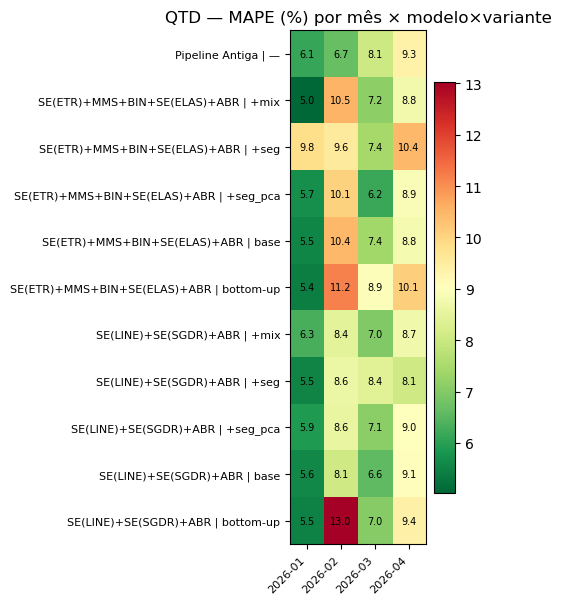

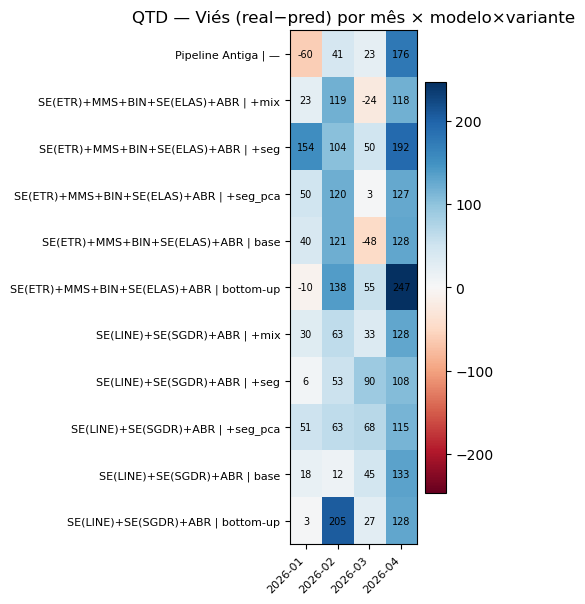


===== VALOR — MAPE médio por mês =====


modelo_variante,"ExtraTrees(EXT,j90) | +mix","ExtraTrees(EXT,j90) | +seg","ExtraTrees(EXT,j90) | +seg_pca","ExtraTrees(EXT,j90) | base","ExtraTrees(EXT,j90) | bottom-up",Pipeline Antiga | —,SE(ETR)+ABR | +mix,SE(ETR)+ABR | +seg,SE(ETR)+ABR | +seg_pca,SE(ETR)+ABR | base,SE(ETR)+ABR | bottom-up,Voting(GBR+XGB+RFR) | +mix,Voting(GBR+XGB+RFR) | +seg,Voting(GBR+XGB+RFR) | +seg_pca,Voting(GBR+XGB+RFR) | base,Voting(GBR+XGB+RFR) | bottom-up
mes,,,,,,,,,,,,,,,,
2026-01,8.24,10.42,9.61,7.90,6.76,7.78,7.87,5.78,6.76,7.89,7.48,7.06,6.09,5.91,7.05,6.68
2026-02,6.03,8.34,6.53,5.52,9.67,7.09,7.07,7.97,6.71,6.88,9.66,8.97,10.16,8.49,8.75,11.57
2026-03,6.03,8.00,6.95,5.76,6.62,7.88,7.17,7.75,7.68,7.43,6.56,6.87,7.96,7.34,6.67,6.64
2026-04,10.29,12.12,11.19,9.80,9.81,11.65,11.36,9.88,10.96,11.56,12.12,10.88,10.32,10.83,11.44,11.17


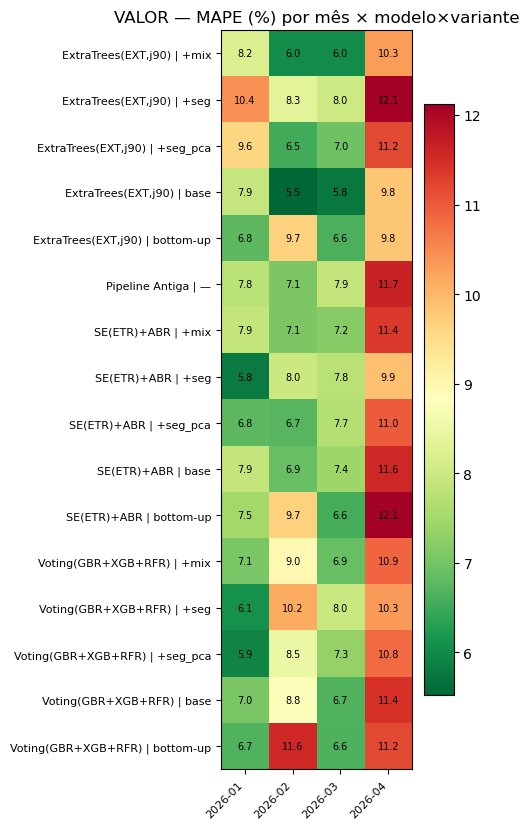

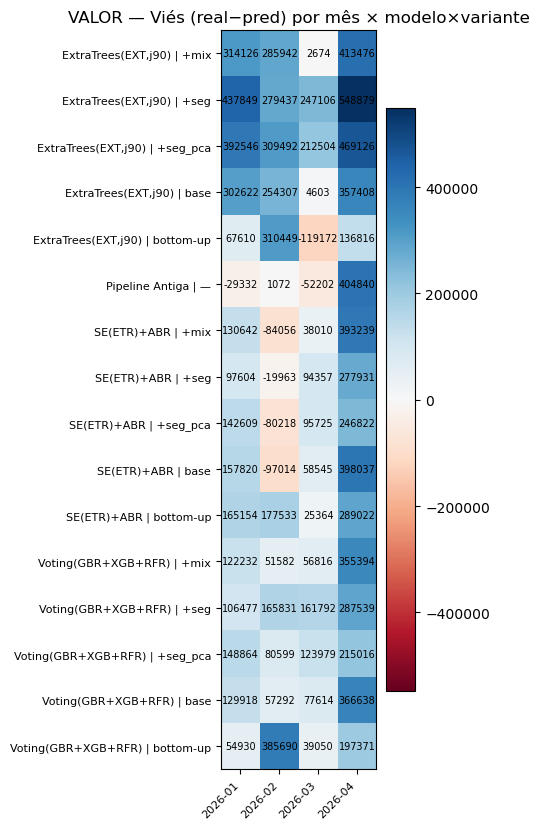

,parte,mes,modelo_variante,MAPE,Vies,MAE,N
0,qtd,2026-01,Pipeline Antiga | —,6.14,-60.55,176.54,21
1,qtd,2026-01,SE(ETR)+MMS+BIN+SE(ELAS)+ABR | +mix,5.03,23.20,147.64,21
2,qtd,2026-01,SE(ETR)+MMS+BIN+SE(ELAS)+ABR | +seg,9.84,153.89,293.27,21
3,qtd,2026-01,SE(ETR)+MMS+BIN+SE(ELAS)+ABR | +seg_pca,5.71,49.61,168.58,21
4,qtd,2026-01,SE(ETR)+MMS+BIN+SE(ELAS)+ABR | base,5.55,40.36,164.04,21
5,qtd,2026-01,SE(ETR)+MMS+BIN+SE(ELAS)+ABR | bottom-up,5.42,-9.55,158.39,21
6,qtd,2026-01,SE(LINE)+SE(SGDR)+ABR | +mix,6.34,30.15,186.95,21
7,qtd,2026-01,SE(LINE)+SE(SGDR)+ABR | +seg,5.52,6.41,161.61,21
8,qtd,2026-01,SE(LINE)+SE(SGDR)+ABR | +seg_pca,5.89,50.84,174.84,21
9,qtd,2026-01,SE(LINE)+SE(SGDR)+ABR | base,5.58,17.73,163.32,21


In [102]:
# ==================== SAFRA MENSAL — mês × modelo×variante × {MAPE, viés} ====================
def safra(parte, metric, agg):
    sub = MASTER[MASTER['parte'] == parte]
    return sub.pivot_table(index='mes', columns='modelo_variante', values=metric, aggfunc=agg)
for parte in ['qtd', 'valor']:
    mape_m = safra(parte, 'ape', 'mean').round(2)
    vies_m = safra(parte, 'erro', 'mean').round(1)
    print(f'\n===== {parte.upper()} — MAPE médio por mês ====='); display(mape_m)
    heatmap(mape_m.T, f'{parte.upper()} — MAPE (%) por mês × modelo×variante', fmt='{:.1f}', cmap='RdYlGn_r')
    heatmap(vies_m.T, f'{parte.upper()} — Viés (real−pred) por mês × modelo×variante', fmt='{:.0f}', cmap='RdBu', center=0)
# tabela longa mês × modelo × {MAPE, ME, MAE}
safra_tbl = (MASTER.groupby(['parte','mes','modelo_variante'])
             .agg(MAPE=('ape','mean'), Vies=('erro','mean'), MAE=('erro_abs','mean'), N=('ape','size'))
             .round(2).reset_index())
display(safra_tbl.head(20))

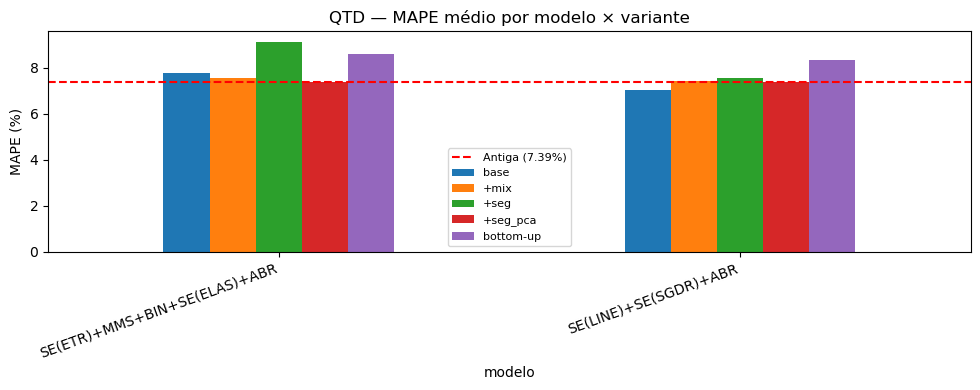

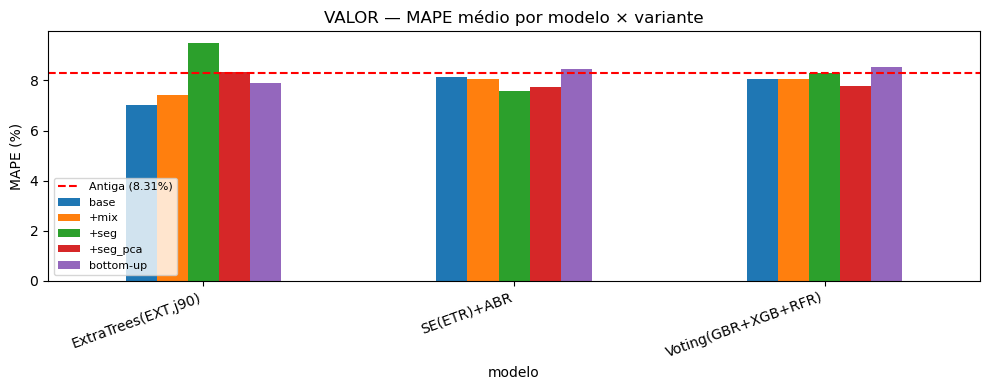

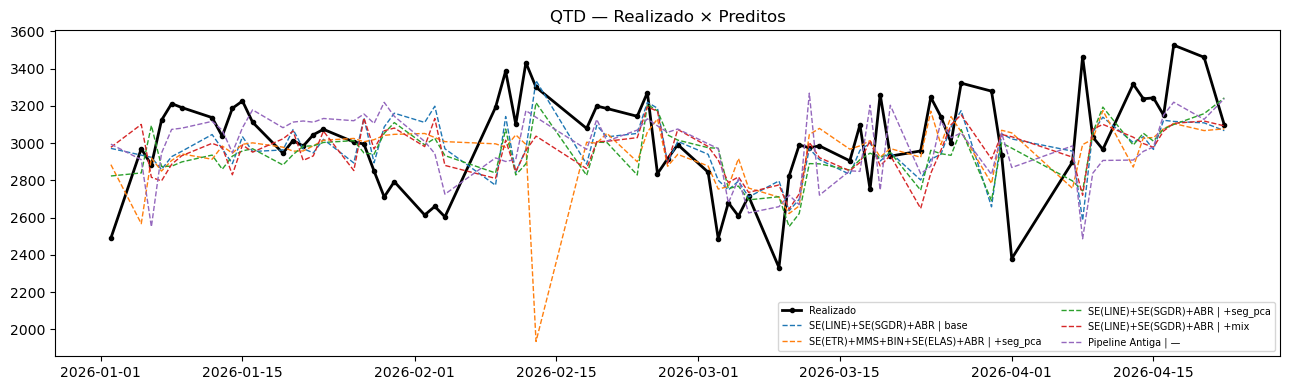

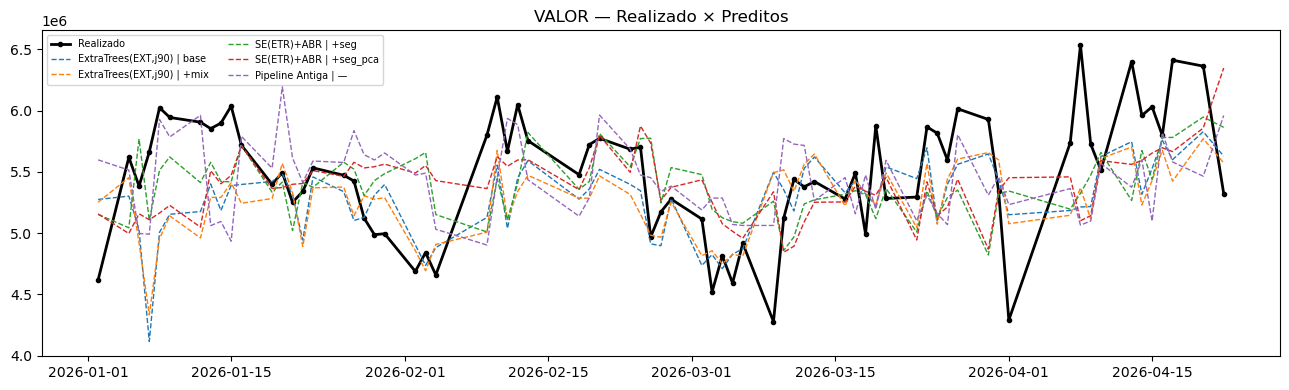

In [103]:
# ==================== GRÁFICOS — MAPE por variante + série temporal realizado×predito ====================
for parte in ['qtd', 'valor']:
    sub = MASTER[(MASTER['parte'] == parte) & (~MASTER['modelo'].str.contains(NOME_ANTIGA))]
    piv = sub.pivot_table(index='modelo', columns='variante', values='ape', aggfunc='mean')
    piv = piv[[c for c in ['base', '+mix', '+seg', '+seg_pca', 'bottom-up'] if c in piv.columns]]
    ax = piv.plot(kind='bar', figsize=(10, 4))
    antiga = MASTER[(MASTER['parte'] == parte) & (MASTER['modelo'].str.contains(NOME_ANTIGA))]['ape'].mean()
    ax.axhline(antiga, color='red', ls='--', label=f'Antiga ({antiga:.2f}%)')
    ax.set_title(f'{parte.upper()} — MAPE médio por modelo × variante'); ax.set_ylabel('MAPE (%)')
    ax.legend(fontsize=8); plt.xticks(rotation=20, ha='right'); plt.tight_layout(); plt.show()

def serie_real_pred(parte, common_dates, realizados, modelos_variante):
    d = sorted(common_dates)
    plt.figure(figsize=(13, 4))
    plt.plot(d, [realizados[t] for t in d], 'k-o', ms=3, lw=2, label='Realizado')
    sub = MASTER[MASTER['parte'] == parte]
    for mv in modelos_variante:
        s = sub[sub['modelo_variante'] == mv].set_index('data')['predito']
        plt.plot(d, [s.get(t, np.nan) for t in d], '--', lw=1, label=mv)
    plt.title(f'{parte.upper()} — Realizado × Preditos'); plt.legend(fontsize=7, ncol=2); plt.tight_layout(); plt.show()

# 4 melhores combinações (por MAPE) + a Pipeline Antiga (sempre, como referência)
def melhores(parte):
    r = ranking_from_master(MASTER, parte)
    top = r['Modelo × Variante'].head(4).tolist()
    antiga = [mv for mv in r['Modelo × Variante'] if NOME_ANTIGA in mv]
    return top + [a for a in antiga if a not in top]
serie_real_pred('qtd',   COMMON_QTD, realizados_qtd, melhores('qtd'))
serie_real_pred('valor', COMMON_VAL, realizados_val, melhores('valor'))

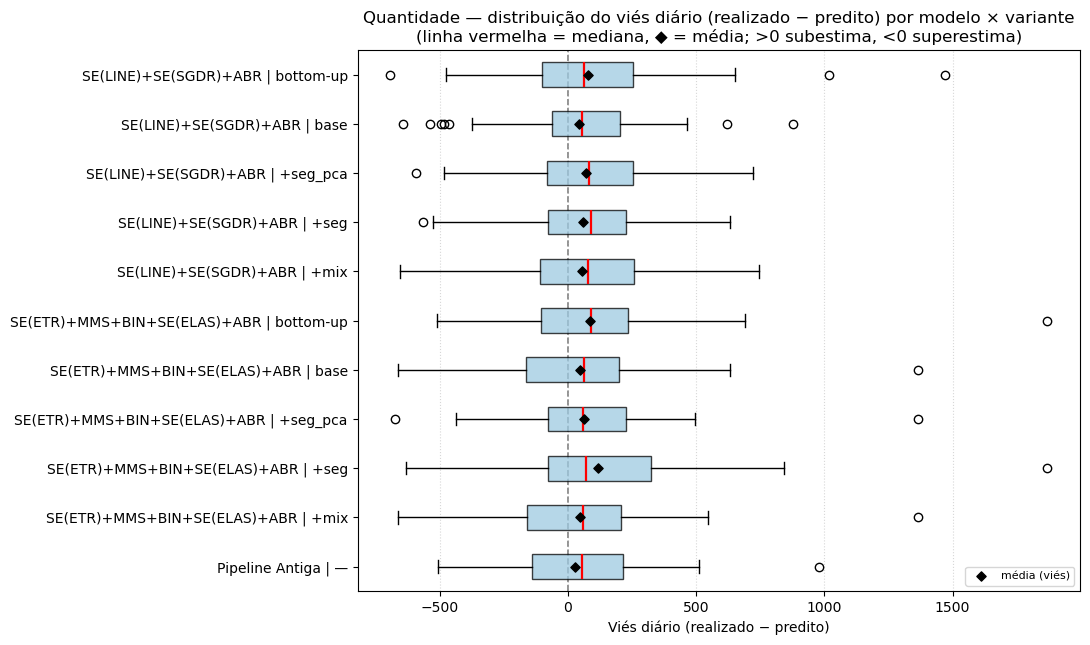

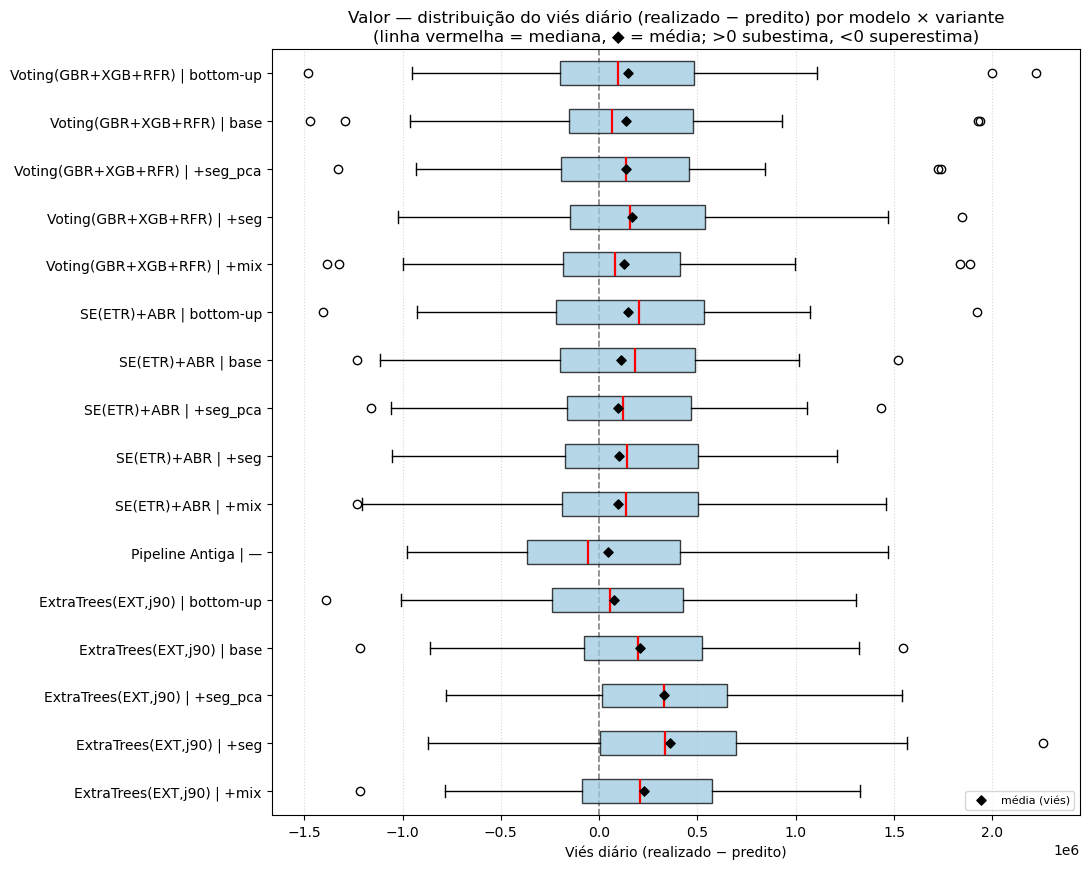

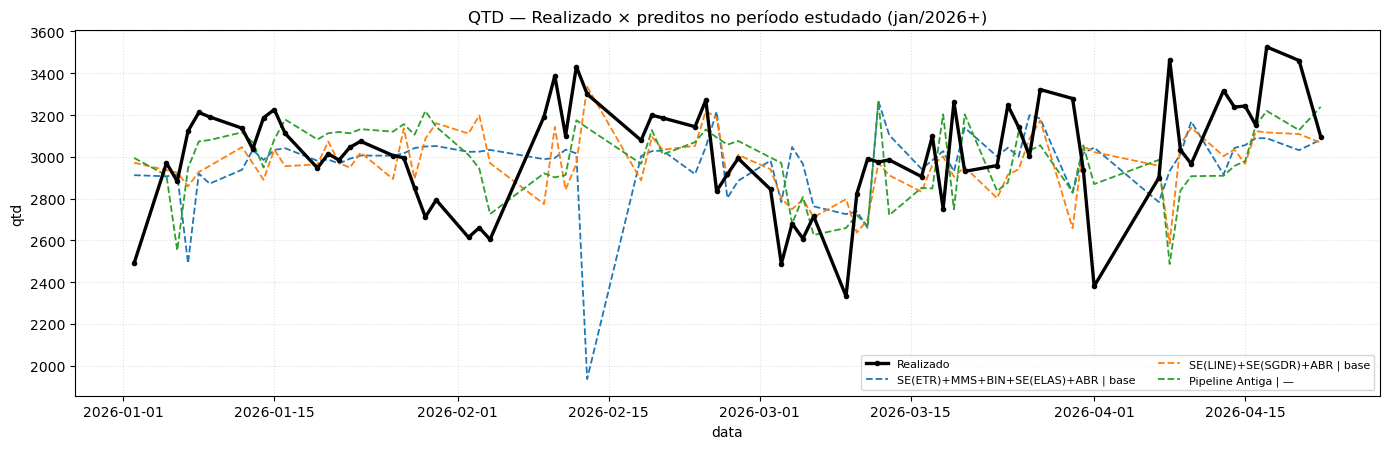

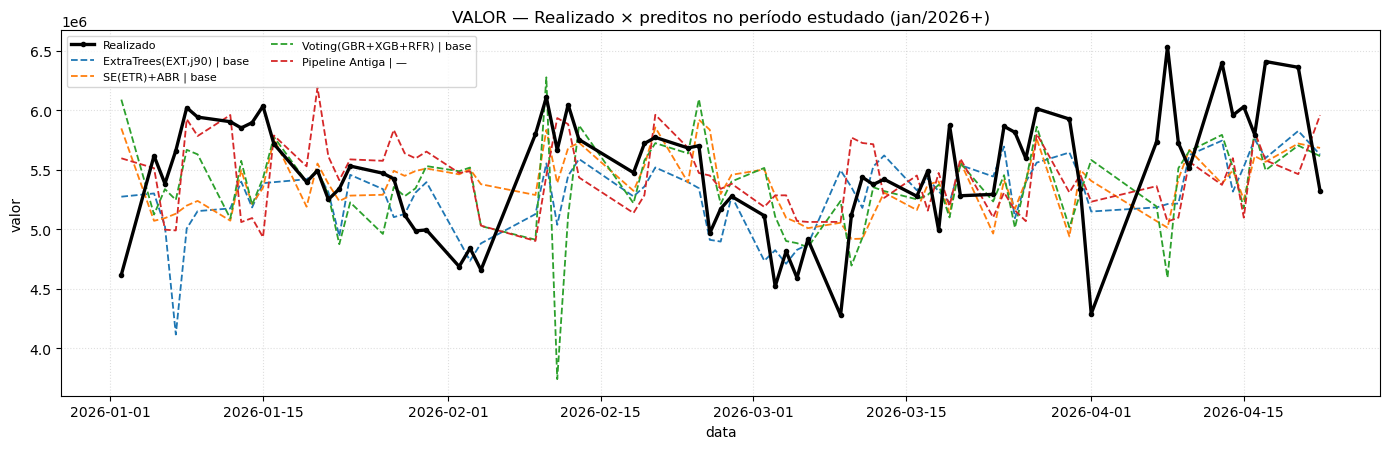

In [104]:
# ==================== DISTRIBUIÇÃO DO MAPE (boxplots) + SÉRIES TEMPORAIS ====================
# --- Boxplots: distribuição do viés diário (realizado − predito) por modelo × variante ---
for parte, unidade in [('qtd', 'Quantidade'), ('valor', 'Valor')]:
    sub = MASTER[MASTER['parte'] == parte]
    ordem = sorted(sub['modelo_variante'].unique().tolist())          # ordem alfabética
    dados = [sub[sub['modelo_variante'] == mv]['erro'].values for mv in ordem]
    fig, ax = plt.subplots(figsize=(11, 0.45*len(ordem) + 1.6))
    bp = ax.boxplot(dados, vert=False, labels=ordem, showfliers=True, patch_artist=True)
    for b in bp['boxes']:    b.set(facecolor='#9ecae1', alpha=0.75)
    for md_ in bp['medians']: md_.set(color='red', lw=1.6)
    medias = [np.mean(x) for x in dados]
    ax.scatter(medias, range(1, len(ordem)+1), marker='D', color='black', s=22, zorder=5, label='média (viés)')
    ax.axvline(0, color='gray', ls='--', lw=1.2, zorder=1)            # 0 = sem viés
    ax.set_title(f'{unidade} — distribuição do viés diário (realizado − predito) por modelo × variante\n(linha vermelha = mediana, ◆ = média; >0 subestima, <0 superestima)')
    ax.set_xlabel('Viés diário (realizado − predito)'); ax.grid(axis='x', ls=':', alpha=0.5); ax.legend(fontsize=8, loc='lower right')
    plt.tight_layout(); plt.show()

# --- Séries temporais: realizado × modelos no período estudado ---
def serie_modelos(parte, common_dates, realizados, variantes_modelo):
    '''Plota o realizado e o predito dos modelos escolhidos ao longo de common_dates.'''
    d = sorted(common_dates)
    sub = MASTER[MASTER['parte'] == parte]
    plt.figure(figsize=(14, 4.6))
    plt.plot(d, [realizados[t] for t in d], 'k-o', ms=3, lw=2.4, label='Realizado', zorder=6)
    for mv in variantes_modelo:
        s = sub[sub['modelo_variante'] == mv].set_index('data')['predito']
        plt.plot(d, [s.get(t, np.nan) for t in d], '--', lw=1.3, label=mv)
    plt.title(f'{parte.upper()} — Realizado × preditos no período estudado (jan/2026+)')
    plt.xlabel('data'); plt.ylabel(parte); plt.legend(fontsize=8, ncol=2); plt.grid(ls=':', alpha=0.4)
    plt.tight_layout(); plt.show()

# por padrão: a variante BASE de cada modelo + a Pipeline Antiga (comparação justa entre arquiteturas)
def _base_e_antiga(parte):
    sub = MASTER[MASTER['parte'] == parte]
    base = sorted(sub[sub['variante'] == 'base']['modelo_variante'].unique().tolist())
    antiga = [mv for mv in sub['modelo_variante'].unique() if NOME_ANTIGA in mv]
    return base + antiga
serie_modelos('qtd',   COMMON_QTD, realizados_qtd, _base_e_antiga('qtd'))
serie_modelos('valor', COMMON_VAL, realizados_val, _base_e_antiga('valor'))

In [105]:
# ==================== EXPORT EXCEL ====================
_out = 'saidas/comparativo_canal_produto.xlsx'
with pd.ExcelWriter(_out) as xl:
    ranking_from_master(MASTER, 'qtd').to_excel(xl, 'ranking_qtd', index=False)
    ranking_from_master(MASTER, 'valor').to_excel(xl, 'ranking_valor', index=False)
    com_vs_sem('qtd', 'ape', 'mean').round(2).to_excel(xl, 'comvssem_qtd')
    com_vs_sem('valor', 'ape', 'mean').round(2).to_excel(xl, 'comvssem_valor')
    safra_tbl.to_excel(xl, 'safra_mensal', index=False)
    nulos_qtd.to_excel(xl, 'nulos_qtd', index=False)
    nulos_val.to_excel(xl, 'nulos_valor', index=False)
    MASTER.to_excel(xl, 'master', index=False)
print(f'Exportado: {_out}')

Exportado: comparativo_canal_produto.xlsx


---
# Roteiro de apresentação — colar no PowerPoint

A célula abaixo gera, **com os números reais do estudo** (extraídos do `MASTER`), um roteiro
**slide a slide** para defender o modelo recomendado e argumentar por que o incremento de
**canal/produto não trouxe melhora**. Cada bloco = 1 slide (título + bullets prontos para colar).

As **tabelas e heatmaps** a colar são os já exibidos nas seções anteriores (rankings, com-vs-sem,
safra). No fim há um **alerta de honestidade**: se alguma variante de canal/produto tiver de fato
reduzido o MAPE de forma relevante, o roteiro avisa para você revisar o argumento antes de defender.

In [106]:
# ==================== ROTEIRO DE APRESENTAÇÃO (colar no PowerPoint) ====================
def _stats(parte):
    r = ranking_from_master(MASTER, parte).copy()
    r['modelo']   = r['Modelo × Variante'].str.rsplit(' | ', n=1).str[0]
    r['variante'] = r['Modelo × Variante'].str.rsplit(' | ', n=1).str[1]
    antiga = float(r.loc[r['Modelo × Variante'].str.contains(NOME_ANTIGA), 'MAPE Médio (%)'].iloc[0])
    cand = r[~r['Modelo × Variante'].str.contains(NOME_ANTIGA)].reset_index(drop=True)
    base_only = cand[cand['variante'] == 'base'].reset_index(drop=True)
    champ   = base_only.iloc[0] if len(base_only) else cand.iloc[0]   # recomendado = melhor variante base
    overall = cand.iloc[0]                                            # melhor de TODAS as variantes
    piv = (MASTER[(MASTER['parte']==parte) & (~MASTER['modelo'].str.contains(NOME_ANTIGA))]
           .pivot_table(index='modelo', columns='variante', values='ape', aggfunc='mean'))
    extra = [c for c in ['+mix','+seg','+seg_pca','bottom-up'] if c in piv.columns]
    dvar = {c: round(float((piv[c]-piv['base']).mean()), 2) for c in extra}   # Δ MAPE vs base, média entre modelos
    return dict(antiga=antiga, champ=champ, overall=overall, dvar=dvar)

def _sl(n, titulo, linhas):
    print('\n' + '='*70); print(f'SLIDE {n} — {titulo}'); print('-'*70)
    for ln in linhas: print(ln)

SQ, SV = _stats('qtd'), _stats('valor')
_txt_q = ' | '.join([f'{k} {v:+.2f}' for k, v in SQ['dvar'].items()])
_txt_v = ' | '.join([f'{k} {v:+.2f}' for k, v in SV['dvar'].items()])

_sl(1, 'Capa', [
 '• Título: Previsão diária de vendas — escolha do modelo',
 '• Subtítulo: O incremento de canal e produto melhora a previsão?',
 f'• Período avaliado: jan/2026+ | qtd: {len(COMMON_QTD)} dias úteis | valor: {len(COMMON_VAL)} dias úteis',
 '• (fala) Dois objetivos: escolher o melhor modelo e testar se canal/produto agrega.'])

_sl(2, 'Pergunta de negócio', [
 '• Hoje a previsão diária roda com um modelo de produção (a "Pipeline Antiga").',
 '• Pergunta 1 — qual modelo prevê melhor a quantidade e o valor das propostas?',
 '• Pergunta 2 — enriquecer o modelo com CANAL e PRODUTO melhora a previsão?',
 '• (fala) Resultado: o melhor modelo supera a antiga; canal/produto NÃO trouxe ganho relevante.'])

_sl(3, 'Como avaliamos (metodologia justa)', [
 '• Walk-forward: para cada dia, re-treina usando só os dias anteriores (janela 45; 90 no ExtraTrees) — nunca olha o futuro.',
 '• Todos os modelos avaliados nas MESMAS datas (interseção) e contra o realizado recomputado da base — comparação justa.',
 '• Dias de incidente operacional (Log_Erro) removidos; domingos/feriados não são previstos.',
 '• Métricas: MAPE (erro % médio), Viés (realizado − predito) e MAE; mais análise de safra mês a mês.'])

_sl(4, 'O que foi testado (5 abordagens × cada modelo)', [
 '• base — modelo de produção, SEM canal/produto.',
 '• +mix — share do canal e do produto dominantes de ontem (2 features).',
 '• +seg — volume de cada canal e cada produto em vários lags (cru, muitas colunas).',
 '• +seg_pca — o mesmo, comprimido por PCA (componentes que somam ≥80% da variância).',
 '• bottom-up — um modelo por célula canal×produto e SOMA das partes (estratégia hierárquica).'])

_sl(5, 'Resultado — Quantidade', [
 f"• Recomendado: {SQ['champ']['modelo']}  (variante base)  →  MAPE {SQ['champ']['MAPE Médio (%)']:.2f}%",
 f"• Pipeline Antiga: {SQ['antiga']:.2f}%   (ganho do recomendado: {SQ['champ']['Δ MAPE vs antiga']:+.2f} p.p.)",
 f"• Melhor de TODAS as variantes testadas: {SQ['overall']['Modelo × Variante']} ({SQ['overall']['MAPE Médio (%)']:.2f}%)",
 '• (colar a tabela RANKING_QTD)'])

_sl(6, 'Resultado — Valor', [
 f"• Recomendado: {SV['champ']['modelo']}  (variante base)  →  MAPE {SV['champ']['MAPE Médio (%)']:.2f}%",
 f"• Pipeline Antiga: {SV['antiga']:.2f}%   (ganho do recomendado: {SV['champ']['Δ MAPE vs antiga']:+.2f} p.p.)",
 f"• Melhor de TODAS as variantes testadas: {SV['overall']['Modelo × Variante']} ({SV['overall']['MAPE Médio (%)']:.2f}%)",
 '• (colar a tabela RANKING_VALOR)'])

_sl(7, 'Canal/produto NÃO melhorou — a evidência', [
 '• Δ MAPE médio de cada variante vs base (negativo = melhora), média entre os modelos:',
 f'   QTD   → {_txt_q}',
 f'   VALOR → {_txt_v}',
 '• Os ganhos são ~0 ou POSITIVOS (pioram): nenhuma variante reduz o erro de forma consistente.',
 '• (colar os pivôs COMVSSEM_QTD / COMVSSEM_VALOR)'])

_sl(8, 'Por que não melhorou (interpretação)', [
 '• O total do dia JÁ embute o mix: os lags do próprio total carregam o efeito agregado de canal/produto.',
 '• +mix acrescenta pouca informação nova e ruidosa — a composição muda muito de um dia para o outro.',
 '• +seg estoura a dimensionalidade (dezenas a ~140 colunas para ~45 linhas de treino) → overfit.',
 '• +seg_pca comprime as colunas, mas o sinal extra é fraco → não recupera ganho real.',
 '• bottom-up: somar ~13 previsões ruidosas ACUMULA erro, e as células perdem a fila (lag_7) e os extras do EXT.',
 '• Conclusão: no grão diário agregado, prever o total direto é mais simples e mais estável.'])

_sl(9, 'Modelo recomendado', [
 f"• Quantidade: {SQ['champ']['modelo']} — MAPE {SQ['champ']['MAPE Médio (%)']:.2f}% ({SQ['champ']['Δ MAPE vs antiga']:+.2f} p.p. vs antiga).",
 f"• Valor: {SV['champ']['modelo']} — MAPE {SV['champ']['MAPE Médio (%)']:.2f}% ({SV['champ']['Δ MAPE vs antiga']:+.2f} p.p. vs antiga).",
 '• Sem canal/produto: modelo mais enxuto, mais estável e já melhor que a Pipeline Antiga.'])

_sl(10, 'Robustez — safra mensal', [
 '• A vantagem do recomendado se mantém mês a mês, não é sorte de um período.',
 '• (colar o heatmap de SAFRA — MAPE por mês × modelo×variante)',
 '• Viés sem tendência sistemática de sub/superestimar.'])

_sl(11, 'Conclusão e recomendação', [
 '• Os modelos recomendados superam a Pipeline Antiga em qtd e valor.',
 '• Canal/produto não compensa a complexidade adicional → manter o modelo enxuto (base).',
 '• Próximos passos: promover o recomendado a produção; só revisitar canal/produto se mudar o objetivo (ex.: prever POR canal).'])

# -------- alerta de honestidade: a tese "não melhorou" bate com os dados? --------
_ganhos = list(SQ['dvar'].values()) + list(SV['dvar'].values())
if _ganhos and min(_ganhos) <= -0.5:
    print('\n' + '!'*70)
    print('[ATENÇÃO] Alguma variante de canal/produto reduziu o MAPE em mais de 0,5 p.p.')
    print('Os dados podem NÃO sustentar o argumento "não melhorou" — revise os slides 7-9 antes de apresentar.')
    print('!'*70)
else:
    print('\n[OK] Os dados sustentam o argumento: nenhuma variante de canal/produto melhora >0,5 p.p.')

print('\n\n########## TABELAS PARA COLAR (já calculadas acima) ##########')
print('\n[RANKING_QTD]');   display(ranking_from_master(MASTER, 'qtd'))
print('\n[RANKING_VALOR]'); display(ranking_from_master(MASTER, 'valor'))


SLIDE 1 — Capa
----------------------------------------------------------------------
• Título: Previsão diária de vendas — escolha do modelo
• Subtítulo: O incremento de canal e produto melhora a previsão?
• Período avaliado: jan/2026+ | qtd: 71 dias úteis | valor: 71 dias úteis
• (fala) Dois objetivos: escolher o melhor modelo e testar se canal/produto agrega.

SLIDE 2 — Pergunta de negócio
----------------------------------------------------------------------
• Hoje a previsão diária roda com um modelo de produção (a "Pipeline Antiga").
• Pergunta 1 — qual modelo prevê melhor a quantidade e o valor das propostas?
• Pergunta 2 — enriquecer o modelo com CANAL e PRODUTO melhora a previsão?
• (fala) Resultado: o melhor modelo supera a antiga; canal/produto NÃO trouxe ganho relevante.

SLIDE 3 — Como avaliamos (metodologia justa)
----------------------------------------------------------------------
• Walk-forward: para cada dia, re-treina usando só os dias anteriores (janela 45; 90 no 

,Modelo × Variante,MAPE Médio (%),MAPE Mediana (%),Viés (real-pred),MAE,N,Δ MAPE vs antiga
0,SE(LINE)+SE(SGDR)+ABR | base,7.04,5.28,44.30,208.60,71,-0.35
1,SE(ETR)+MMS+BIN+SE(ELAS)+ABR | +seg_pca,7.38,6.46,64.00,220.70,71,-0.01
2,SE(LINE)+SE(SGDR)+ABR | +seg_pca,7.40,7.05,69.80,221.00,71,0.01
3,SE(LINE)+SE(SGDR)+ABR | +mix,7.42,6.28,54.90,220.60,71,0.03
4,SE(ETR)+MMS+BIN+SE(ELAS)+ABR | +mix,7.55,6.22,46.20,225.20,71,0.16
5,SE(LINE)+SE(SGDR)+ABR | +seg,7.55,6.48,59.80,224.40,71,0.16
6,SE(ETR)+MMS+BIN+SE(ELAS)+ABR | base,7.78,6.35,45.90,231.90,71,0.39
7,SE(LINE)+SE(SGDR)+ABR | bottom-up,8.32,6.07,77.00,249.40,71,0.93
8,SE(ETR)+MMS+BIN+SE(ELAS)+ABR | bottom-up,8.60,6.16,87.20,258.50,71,1.21
9,SE(ETR)+MMS+BIN+SE(ELAS)+ABR | +seg,9.13,8.39,117.00,274.40,71,1.74



[RANKING_VALOR]


,Modelo × Variante,MAPE Médio (%),MAPE Mediana (%),Viés (real-pred),MAE,N,Δ MAPE vs antiga
0,"ExtraTrees(EXT,j90) | base",7.02,5.75,208649.80,389169.00,71,-1.29
1,"ExtraTrees(EXT,j90) | +mix",7.40,5.85,228060.10,411409.80,71,-0.91
2,SE(ETR)+ABR | +seg,7.58,6.52,100581.70,411055.80,71,-0.73
3,SE(ETR)+ABR | +seg_pca,7.74,6.84,95480.60,419210.20,71,-0.57
4,Voting(GBR+XGB+RFR) | +seg_pca,7.77,6.85,136950.20,423662.80,71,-0.54
5,"ExtraTrees(EXT,j90) | bottom-up",7.89,6.92,76155.20,427449.20,71,-0.42
6,SE(ETR)+ABR | +mix,8.06,6.63,97939.30,436350.40,71,-0.25
7,Voting(GBR+XGB+RFR) | base,8.06,6.86,137353.90,438684.50,71,-0.25
8,Voting(GBR+XGB+RFR) | +mix,8.08,6.31,125449.10,438345.40,71,-0.23
9,SE(ETR)+ABR | base,8.14,6.22,110231.50,441853.00,71,-0.17
